In [1]:
import pandas as pd
import numpy as np

In [2]:
import os

file_cities = os.path.join('./data','cities_data.csv')
df_cities = pd.read_csv(file_cities, sep=';')

file_orders = os.path.join('./data','orders.csv')
df_orders = pd.read_csv(file_orders, sep=';')

file_product = os.path.join('./data','product_attributes.csv')
df_product = pd.read_csv(file_product)

In [3]:
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [4]:
df_cities.shape

(666, 5)

In [5]:
df_orders.shape

(114276, 9)

In [6]:
df_product.shape

(772, 3)

In [7]:
df_product['material_handling'].value_counts()

material_handling
5    263
3    159
2    127
0     93
4     89
1     41
Name: count, dtype: int64

In [8]:
df_orders.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False


In [9]:
df_cities.head()

,city_from_name,city_to_name,city_from_coord,city_to_coord,distance
0,Dusseldorf,Zaragoza,"(51.2254018, 6.7763137)","(41.6521342, -0.8809428)",1214.477
1,Dusseldorf,Venlo,"(51.2254018, 6.7763137)","(51.39244885, 6.1511724144122955)",47.388
2,Dusseldorf,Bratislava,"(51.2254018, 6.7763137)","(48.1516988, 17.1093063)",819.289
3,Dusseldorf,Hamburg,"(51.2254018, 6.7763137)","(53.550341, 10.000654)",339.221
4,Dusseldorf,Rome,"(51.2254018, 6.7763137)","(41.8933203, 12.4829321)",1125.029


In [10]:
df_product.head()

,product_id,weight,material_handling
0,1672707,2876,3
1,1694456,2785,5
2,1682865,2751,3
3,1689146,2736,0
4,1664069,2707,4


In [11]:
df_orders['origin_port'].unique()

array(['Rotterdam', 'Athens', 'Barcelona', 'BCN', 'ATHENAS'], dtype=object)

In [12]:
df_orders['customer'].unique()

array(['Marseille', 'Paris', 'Milan', 'Berlin', 'Munich', 'Prague',
       'Rome', 'Madrid', 'Naples', 'Athens', 'Lisbon', 'Turin', 'Vienna',
       'Stockholm', 'Barcelona', 'Amsterdam', 'Valencia', 'Cologne',
       'Malmö', 'Budapest', 'Hanover', 'Helsinki', 'Copenhagen',
       'Bucharest', 'Bremen', 'Lyon', 'Porto', 'Bordeaux'], dtype=object)

In [13]:
df_cities['city_to_name'].unique()

array(['Zaragoza', 'Venlo', 'Bratislava', 'Hamburg', 'Rome', 'Lille',
       'Liege', 'Warsaw', 'Paris', 'Lyon', 'Marseille', 'Bordeaux',
       'Milan', 'Berlin', 'Madrid', 'Vienna', 'Munich', 'Amsterdam',
       'Stockholm', 'Copenhagen', 'Barcelona', 'Cologne', 'Athens',
       'Bucharest', 'Budapest', 'Naples', 'Lisbon', 'Turin', 'Hanover',
       'Malmö', 'Helsinki', 'Prague', 'Valencia', 'Bremen', 'Porto',
       'Dusseldorf'], dtype=object)

In [14]:
df_orders['logistic_hub'].unique()

array(['Venlo', 'Rome', 'Lille', 'Bratislava', 'Warsaw', nan,
       'Dusseldorf', 'Hamburg', 'Liege', 'Zaragoza'], dtype=object)

In [15]:
df_merge = pd.merge(df_orders, df_product, on='product_id', how='left')

In [16]:
df_merge.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order,weight,material_handling
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True,1778.000,5.000
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False,1088.000,3.000
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True,505.000,4.000
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False,1308.000,4.000
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False,1465.000,0.000


In [17]:
df_merge['logistic_hub'].isnull().sum()

np.int64(1049)

In [18]:
df_merge['origin_port'] = df_merge['origin_port'].replace({'ATHENAS': 'Athens', 'BCN': 'Barcelona'})
df_merge['customer'] = df_merge['customer'].replace({'ATHENAS': 'Athens', 'BCN': 'Barcelona'})

In [19]:
cities = df_cities.copy()

In [20]:
cities = df_cities.rename(columns={
    "city_from_name": "from_city",
    "city_to_name": "to_city",
    "distance": "distance_km"
})

In [21]:
cities_rev = cities.rename(columns={
    "from_city": "to_city",
    "to_city": "from_city"
})

cities_full = pd.concat([cities, cities_rev], ignore_index=True)

In [22]:
cities_full.head()

,from_city,to_city,city_from_coord,city_to_coord,distance_km
0,Dusseldorf,Zaragoza,"(51.2254018, 6.7763137)","(41.6521342, -0.8809428)",1214.477
1,Dusseldorf,Venlo,"(51.2254018, 6.7763137)","(51.39244885, 6.1511724144122955)",47.388
2,Dusseldorf,Bratislava,"(51.2254018, 6.7763137)","(48.1516988, 17.1093063)",819.289
3,Dusseldorf,Hamburg,"(51.2254018, 6.7763137)","(53.550341, 10.000654)",339.221
4,Dusseldorf,Rome,"(51.2254018, 6.7763137)","(41.8933203, 12.4829321)",1125.029


In [23]:
port_to_hub = cities_full.rename(columns={
    "from_city": "origin_port",
    "to_city": "logistic_hub",
    "distance_km": "dist_port_to_hub"
})

In [24]:
port_to_hub

,origin_port,logistic_hub,city_from_coord,city_to_coord,dist_port_to_hub
0,Dusseldorf,Zaragoza,"(51.2254018, 6.7763137)","(41.6521342, -0.8809428)",1214.477
1,Dusseldorf,Venlo,"(51.2254018, 6.7763137)","(51.39244885, 6.1511724144122955)",47.388
2,Dusseldorf,Bratislava,"(51.2254018, 6.7763137)","(48.1516988, 17.1093063)",819.289
3,Dusseldorf,Hamburg,"(51.2254018, 6.7763137)","(53.550341, 10.000654)",339.221
4,Dusseldorf,Rome,"(51.2254018, 6.7763137)","(41.8933203, 12.4829321)",1125.029
...,...,...,...,...,...
1327,Helsinki,Rotterdam,"(51.9244424, 4.47775)","(60.1674881, 24.9427473)",1560.648
1328,Prague,Rotterdam,"(51.9244424, 4.47775)","(50.0874654, 14.4212535)",726.558
1329,Valencia,Rotterdam,"(51.9244424, 4.47775)","(39.4697065, -0.3763353)",1434.150
1330,Bremen,Rotterdam,"(51.9244424, 4.47775)","(53.0758196, 8.8071646)",320.646


In [25]:
df_merge = df_merge.merge(
    port_to_hub[["origin_port", "logistic_hub", "dist_port_to_hub"]],
    on=["origin_port", "logistic_hub"],
    how="left"
)

In [26]:
df_merge.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order,weight,material_handling,dist_port_to_hub
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True,1778.000,5.000,130.046
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False,1088.000,3.000,1269.236
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True,505.000,4.000,2029.573
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False,1308.000,4.000,173.964
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False,1465.000,0.000,1153.418


In [27]:
hub_to_customer = cities_full.rename(columns={
    "from_city": "logistic_hub",
    "to_city": "customer",
    "distance_km": "dist_hub_to_customer"
})

In [28]:
df_merge = df_merge.merge(
    hub_to_customer[["logistic_hub", "customer", "dist_hub_to_customer"]],
    on=["logistic_hub", "customer"],
    how="left"
)

In [29]:
df_merge.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order,weight,material_handling,dist_port_to_hub,dist_hub_to_customer
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True,1778.000,5.000,130.046,902.042
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False,1088.000,3.000,1269.236,604.022
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True,505.000,4.000,2029.573,392.925
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False,1308.000,4.000,173.964,733.878
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False,1465.000,0.000,1153.418,512.819


In [30]:
port_to_customer = cities_full.rename(columns={
    "from_city": "origin_port",
    "to_city": "customer",
    "distance_km": "dist_port_to_customer_direct"
})

In [31]:
df_merge = df_merge.merge(
    port_to_customer[["origin_port", "customer", "dist_port_to_customer_direct"]],
    on=["origin_port", "customer"],
    how="left"
)

In [32]:
df_merge.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order,weight,material_handling,dist_port_to_hub,dist_hub_to_customer,dist_port_to_customer_direct
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True,1778.000,5.000,130.046,902.042,961.635
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False,1088.000,3.000,1269.236,604.022,961.635
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True,505.000,4.000,2029.573,392.925,2101.294
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False,1308.000,4.000,173.964,733.878,797.351
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False,1465.000,0.000,1153.418,512.819,1499.697


In [33]:
df_merge['logistic_hub'].isnull().sum()

np.int64(1049)

In [34]:
(df_merge['logistic_hub'] == df_merge['origin_port']).sum()

np.int64(0)

In [35]:
(df_merge['logistic_hub'] == df_merge['customer']).sum()

np.int64(420)

In [36]:
df_merge.isnull().sum()

order_id                           0
origin_port                        0
3pl                                0
customs_procedures                 0
logistic_hub                    1049
customer                           0
product_id                         0
units                              0
late_order                         0
weight                           118
material_handling                118
dist_port_to_hub                1049
dist_hub_to_customer            1469
dist_port_to_customer_direct    1509
dtype: int64

Creo Collona "distance" = Port -> Customer

In [37]:
df_merge["distance"] = df_merge["dist_port_to_customer_direct"]

Port -> Hub -> Cutomer

In [38]:
mask_two_leg = df_merge["dist_port_to_hub"].notna() & df_merge["dist_hub_to_customer"].notna()
df_merge.loc[mask_two_leg, "distance"] = (
    df_merge["dist_port_to_hub"] + df_merge["dist_hub_to_customer"])

Port -> Hub = Customer

In [39]:
mask_same_hub_customer = (
    df_merge["logistic_hub"].notna() &
    (df_merge["logistic_hub"] == df_merge["customer"]) &
    df_merge["dist_port_to_hub"].notna()
)

df_merge.loc[mask_same_hub_customer, "distance"] = df_merge["dist_port_to_hub"]

Port = Customer

In [40]:
mask_same_port_customer = df_merge["origin_port"] == df_merge["customer"]
df_merge.loc[mask_same_port_customer, "distance"] = 0

In [41]:
df_merge.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order,weight,material_handling,dist_port_to_hub,dist_hub_to_customer,dist_port_to_customer_direct,distance
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True,1778.000,5.000,130.046,902.042,961.635,1032.088
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False,1088.000,3.000,1269.236,604.022,961.635,1873.258
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True,505.000,4.000,2029.573,392.925,2101.294,2422.497
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False,1308.000,4.000,173.964,733.878,797.351,907.843
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False,1465.000,0.000,1153.418,512.819,1499.697,1666.237


In [42]:
df_merge['customs_procedures'].dtype

dtype('O')

In [43]:
df_merge['customs_procedures'].value_counts()

customs_procedures
CRF    51477
DTD    43484
DTP    19315
Name: count, dtype: int64

In [44]:
df_merge.isnull().sum()

order_id                           0
origin_port                        0
3pl                                0
customs_procedures                 0
logistic_hub                    1049
customer                           0
product_id                         0
units                              0
late_order                         0
weight                           118
material_handling                118
dist_port_to_hub                1049
dist_hub_to_customer            1469
dist_port_to_customer_direct    1509
distance                           0
dtype: int64

In [45]:
df_merge.shape

(114276, 15)

Drop i missing

In [46]:
df_merge = df_merge.dropna(subset=["weight", "material_handling"])

In [47]:
df_merge.isnull().sum()

order_id                           0
origin_port                        0
3pl                                0
customs_procedures                 0
logistic_hub                    1049
customer                           0
product_id                         0
units                              0
late_order                         0
weight                             0
material_handling                  0
dist_port_to_hub                1049
dist_hub_to_customer            1469
dist_port_to_customer_direct    1507
distance                           0
dtype: int64

C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\1834710891.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_merge["late_order"], palette="coolwarm")


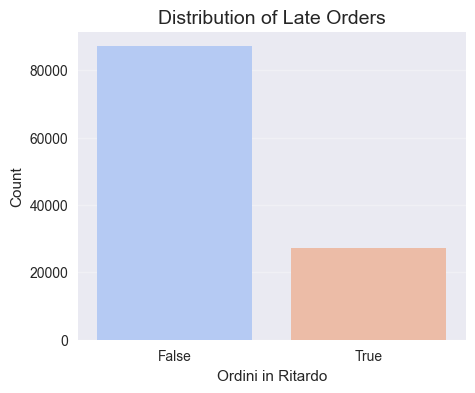

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
plt.style.use('seaborn-v0_8')
sns.countplot(x=df_merge["late_order"], palette="coolwarm")
plt.title("Distribution of Late Orders", fontsize=14)
plt.xlabel("Ordini in Ritardo")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.xticks([0,1], ["False", "True"])
plt.show()

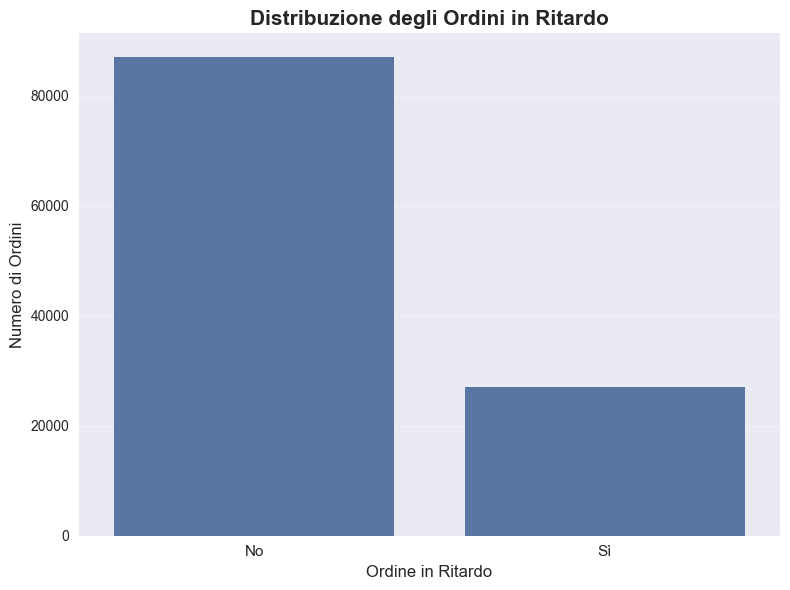

In [49]:

plt.figure(figsize=(8,6))
sns.countplot(
    x=df_merge["late_order"])

plt.title("Distribuzione degli Ordini in Ritardo", fontsize=15, weight="bold")
plt.xlabel("Ordine in Ritardo", fontsize=12)
plt.ylabel("Numero di Ordini", fontsize=12)
plt.grid(axis="y", alpha=0.25)
plt.xticks([0,1], ["No", "Sì"], fontsize=11)

plt.tight_layout()
plt.show()

In [50]:
df_merge["late_order"].value_counts().sort_index()

late_order
False    87035
True     27123
Name: count, dtype: int64

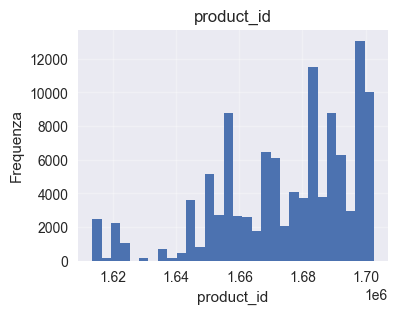

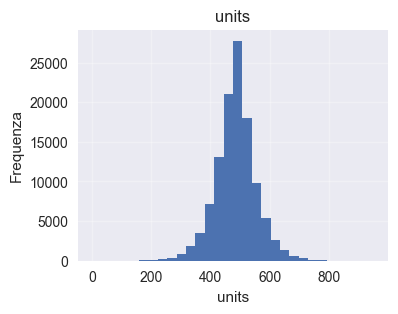

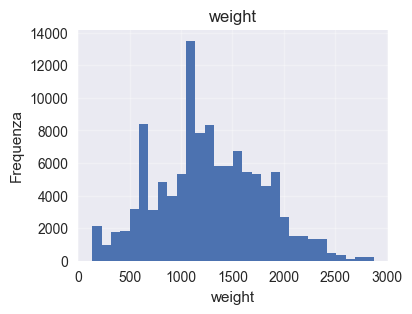

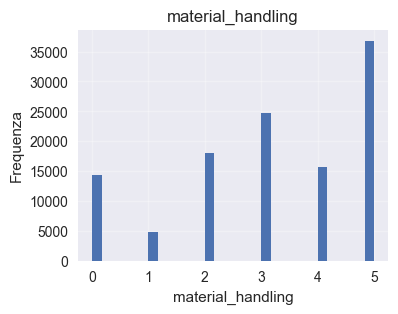

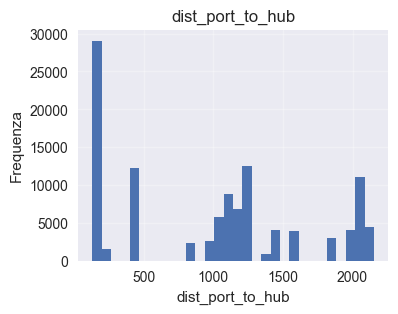

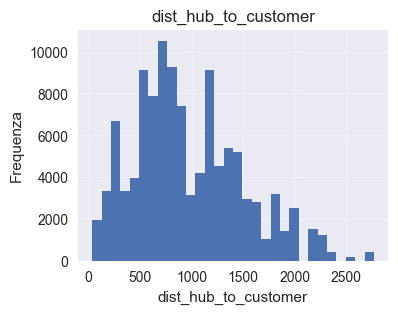

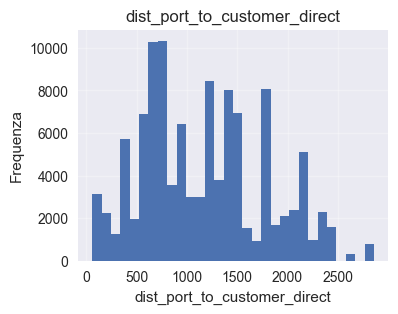

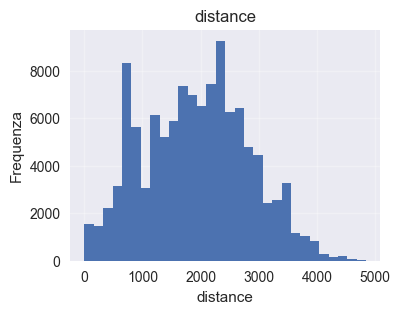

In [51]:
numeric_cols = df_merge.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(4,3))
    plt.hist(df_merge[col].dropna(), bins=30)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequenza")
    plt.grid(alpha=0.3)
    plt.show()

In [52]:
df_merge.describe().T

,count,mean,std,min,25%,50%,75%,max
product_id,114158.000,1675141.685,21811.998,1613321.000,1658532.000,1681687.000,1692987.000,1702654.000
units,114158.000,484.926,68.392,1.000,447.000,486.000,522.000,951.000
weight,114158.000,1267.071,513.034,136.000,901.000,1243.000,1639.000,2876.000
material_handling,114158.000,3.167,1.689,0.000,2.000,3.000,5.000,5.000
dist_port_to_hub,113109.000,1001.209,686.162,130.046,177.308,1135.645,1473.625,2153.580
dist_hub_to_customer,112689.000,969.019,528.678,34.429,580.017,859.988,1319.680,2768.966
dist_port_to_customer_direct,112651.000,1171.207,612.856,57.434,686.260,1157.259,1549.091,2858.622
distance,114158.000,1917.180,911.867,0.000,1226.472,1947.105,2562.050,4849.030


In [53]:
df_merge.describe(percentiles = np.arange(0, 1, .1)).T

,count,mean,std,min,0%,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
product_id,114158.000,1675141.685,21811.998,1613321.000,1613321.000,1646393.000,1657013.000,1666295.000,1672344.000,1681687.000,1683935.000,1690004.000,1696748.000,1699570.000,1702654.000
units,114158.000,484.926,68.392,1.000,1.000,403.000,436.000,457.000,472.000,486.000,498.000,513.000,534.000,566.000,951.000
weight,114158.000,1267.071,513.034,136.000,136.000,598.000,806.000,1019.000,1093.000,1243.000,1351.000,1540.000,1723.000,1895.000,2876.000
material_handling,114158.000,3.167,1.689,0.000,0.000,0.000,2.000,2.000,3.000,3.000,4.000,5.000,5.000,5.000,5.000
dist_port_to_hub,113109.000,1001.209,686.162,130.046,130.046,130.046,177.308,414.449,995.718,1135.645,1153.418,1269.236,1597.091,2025.221,2153.580
dist_hub_to_customer,112689.000,969.019,528.678,34.429,34.429,289.968,523.899,639.411,747.918,859.988,1090.648,1211.130,1418.725,1751.961,2768.966
dist_port_to_customer_direct,112651.000,1171.207,612.856,57.434,57.434,373.889,659.841,726.558,875.080,1157.259,1282.640,1463.954,1801.339,2101.294,2858.622
distance,114158.000,1917.180,911.867,0.000,0.000,678.663,1008.547,1357.476,1669.563,1947.105,2201.851,2422.497,2698.435,3133.843,4849.030


In [54]:
df_merge.describe(percentiles = np.arange(0, 1, .05)).T

,count,mean,std,min,0%,5%,10%,15%,20%,25%,...,55%,60%,65%,70%,75%,80%,85%,90%,95%,max
product_id,114158.000,1675141.685,21811.998,1613321.000,1613321.000,1622685.000,1646393.000,1652499.000,1657013.000,1658532.000,...,1682805.000,1683935.000,1688587.000,1690004.000,1692987.000,1696748.000,1699248.000,1699570.000,1699954.000,1702654.000
units,114158.000,484.926,68.392,1.000,1.000,372.000,403.000,422.000,436.000,447.000,...,492.000,498.000,505.000,513.000,522.000,534.000,548.000,566.000,597.000,951.000
weight,114158.000,1267.071,513.034,136.000,136.000,446.000,598.000,674.000,806.000,901.000,...,1308.000,1351.000,1462.000,1540.000,1639.000,1723.000,1842.000,1895.000,2127.000,2876.000
material_handling,114158.000,3.167,1.689,0.000,0.000,0.000,0.000,1.000,2.000,2.000,...,4.000,4.000,4.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
dist_port_to_hub,113109.000,1001.209,686.162,130.046,130.046,130.046,130.046,173.964,177.308,177.308,...,1135.645,1153.418,1212.185,1269.236,1473.625,1597.091,1984.437,2025.221,2029.573,2153.580
dist_hub_to_customer,112689.000,969.019,528.678,34.429,34.429,231.195,289.968,477.322,523.899,580.017,...,928.233,1090.648,1149.464,1211.130,1319.680,1418.725,1525.293,1751.961,1977.339,2768.966
dist_port_to_customer_direct,112651.000,1171.207,612.856,57.434,57.434,303.449,373.889,612.144,659.841,686.260,...,1184.832,1282.640,1424.528,1463.954,1549.091,1801.339,1881.701,2101.294,2280.615,2858.622
distance,114158.000,1917.180,911.867,0.000,0.000,522.971,678.663,826.394,1008.547,1226.472,...,2078.972,2201.851,2322.745,2422.497,2562.050,2698.435,2872.332,3133.843,3433.489,4849.030


In [55]:
df_merge.describe(percentiles = np.arange(0, 1, .02)).T

,count,mean,std,min,0%,2%,4%,6%,8%,10%,...,82%,84%,86%,88%,90%,92%,94%,96%,98%,max
product_id,114158.000,1675141.685,21811.998,1613321.000,1613321.000,1613321.000,1620552.000,1639636.000,1644308.000,1646393.000,...,1697085.000,1699172.000,1699318.000,1699425.000,1699570.000,1699696.000,1699836.000,1700118.000,1700738.000,1702654.000
units,114158.000,484.926,68.392,1.000,1.000,334.000,362.000,380.000,393.000,403.000,...,539.000,545.000,551.000,558.000,566.000,576.000,590.000,606.000,637.000,951.000
weight,114158.000,1267.071,513.034,136.000,136.000,258.000,396.000,505.000,561.000,598.000,...,1766.000,1830.000,1853.000,1895.000,1895.000,1988.000,2070.000,2199.000,2369.000,2876.000
material_handling,114158.000,3.167,1.689,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
dist_port_to_hub,113109.000,1001.209,686.162,130.046,130.046,130.046,130.046,130.046,130.046,130.046,...,1870.106,1984.437,2008.863,2025.221,2025.221,2029.573,2029.573,2029.573,2153.580,2153.580
dist_hub_to_customer,112689.000,969.019,528.678,34.429,34.429,132.036,197.927,254.694,270.062,289.968,...,1436.924,1473.625,1539.766,1616.815,1751.961,1788.267,1870.106,2025.221,2210.093,2768.966
dist_port_to_customer_direct,112651.000,1171.207,612.856,57.434,57.434,57.434,204.520,338.163,373.889,373.889,...,1803.401,1809.379,1881.701,1975.617,2101.294,2156.641,2166.137,2375.322,2407.423,2858.622
distance,114158.000,1917.180,911.867,0.000,0.000,264.615,405.160,590.927,662.523,678.663,...,2769.085,2837.243,2923.912,2999.893,3133.843,3246.786,3405.148,3473.461,3777.181,4849.030


In [56]:
df_merge.describe(percentiles = np.arange(0, 1, .01)).T

,count,mean,std,min,0%,1%,2%,3%,4%,5%,...,91%,92%,93%,94%,95%,96%,97%,98%,99%,max
product_id,114158.000,1675141.685,21811.998,1613321.000,1613321.000,1613321.000,1613321.000,1620510.000,1620552.000,1622685.000,...,1699666.000,1699696.000,1699793.000,1699836.000,1699954.000,1700118.000,1700141.000,1700738.000,1701406.000,1702654.000
units,114158.000,484.926,68.392,1.000,1.000,305.000,334.000,350.000,362.000,372.000,...,571.000,576.000,582.000,590.000,597.000,606.000,619.000,637.000,663.000,951.000
weight,114158.000,1267.071,513.034,136.000,136.000,185.000,258.000,338.000,396.000,446.000,...,1936.000,1988.000,2016.000,2070.000,2127.000,2199.000,2259.000,2369.000,2483.000,2876.000
material_handling,114158.000,3.167,1.689,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
dist_port_to_hub,113109.000,1001.209,686.162,130.046,130.046,130.046,130.046,130.046,130.046,130.046,...,2029.573,2029.573,2029.573,2029.573,2029.573,2029.573,2138.367,2153.580,2153.580,2153.580
dist_hub_to_customer,112689.000,969.019,528.678,34.429,34.429,75.846,132.036,139.263,197.927,231.195,...,1787.402,1788.267,1857.053,1870.106,1977.339,2025.221,2153.580,2210.093,2297.844,2768.966
dist_port_to_customer_direct,112651.000,1171.207,612.856,57.434,57.434,57.434,57.434,204.520,204.520,303.449,...,2137.917,2156.641,2156.641,2166.137,2280.615,2375.322,2375.322,2407.423,2468.512,2858.622
distance,114158.000,1917.180,911.867,0.000,0.000,0.000,264.615,359.489,405.160,522.971,...,3188.620,3246.786,3308.848,3405.148,3433.489,3473.461,3575.597,3777.181,3904.611,4849.030


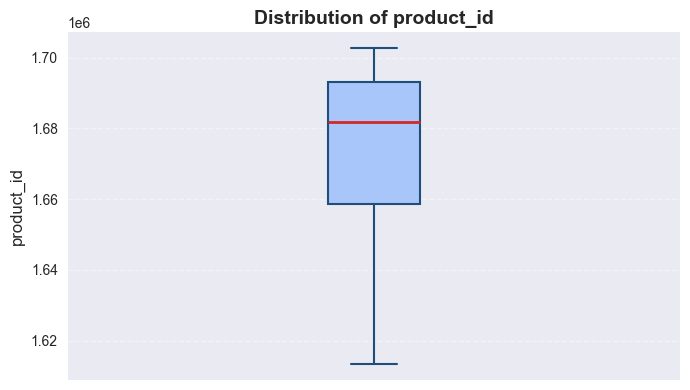

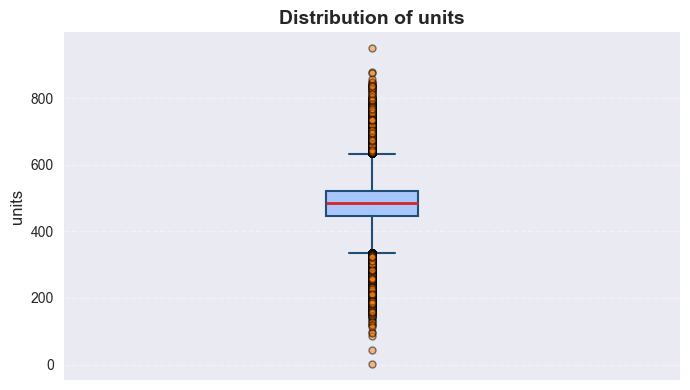

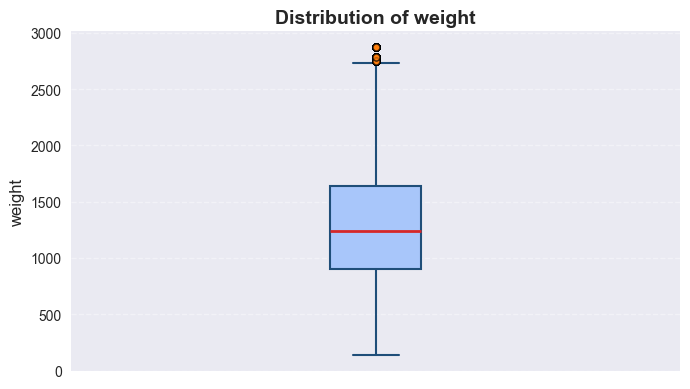

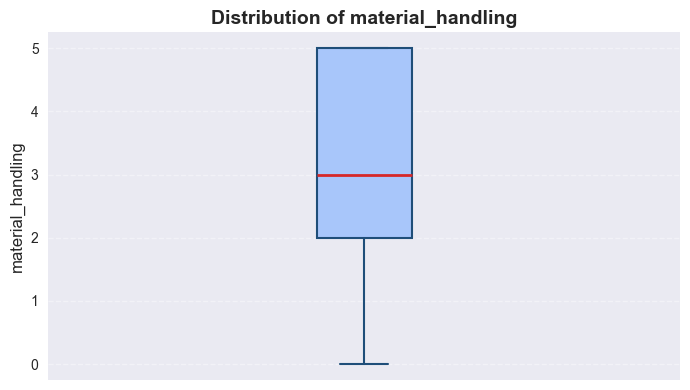

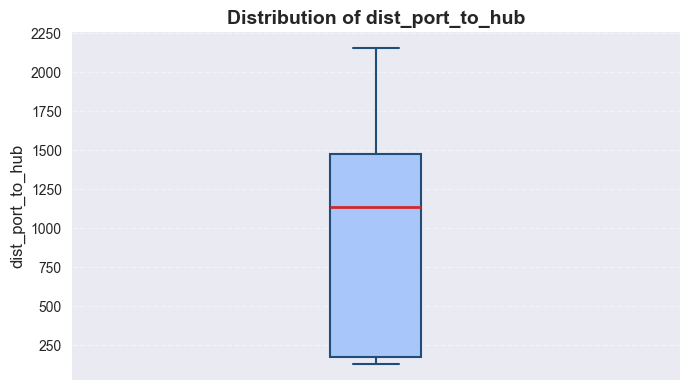

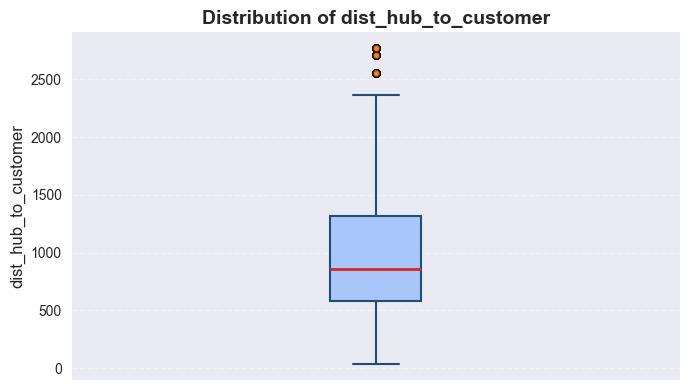

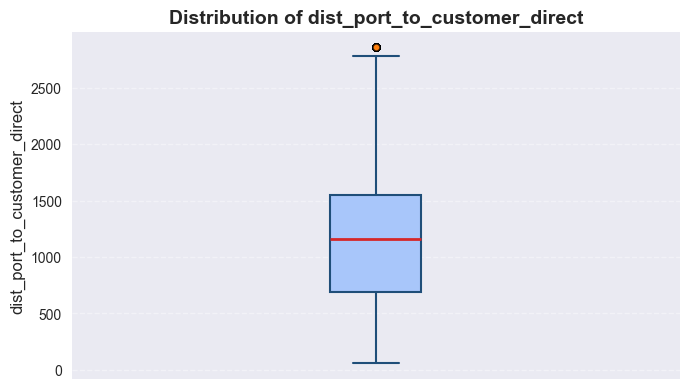

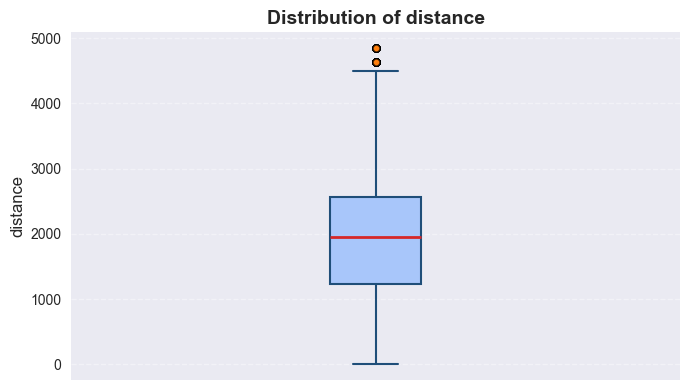

In [57]:
numeric_cols = df_merge.select_dtypes(include="number").columns

for col in numeric_cols:
    data = df_merge[col].dropna()

    plt.figure(figsize=(7,4))

    plt.boxplot(
        data, 
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#a8c6fa", color="#1f4e79", linewidth=1.5),
        medianprops=dict(color="#d62728", linewidth=2),
        whiskerprops=dict(color="#1f4e79", linewidth=1.5),
        capprops=dict(color="#1f4e79", linewidth=1.5),
        flierprops=dict(marker='o', markersize=5, markerfacecolor="#ff7f0e", alpha=0.5)
    )

    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.ylabel(col, fontsize=12)
    plt.xticks([]) 
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [58]:
low_units = df_merge["units"].quantile(0.005)
high_units = df_merge["units"].quantile(0.995)

low_weight = df_merge["weight"].quantile(0.005)
high_weight = df_merge["weight"].quantile(0.995)

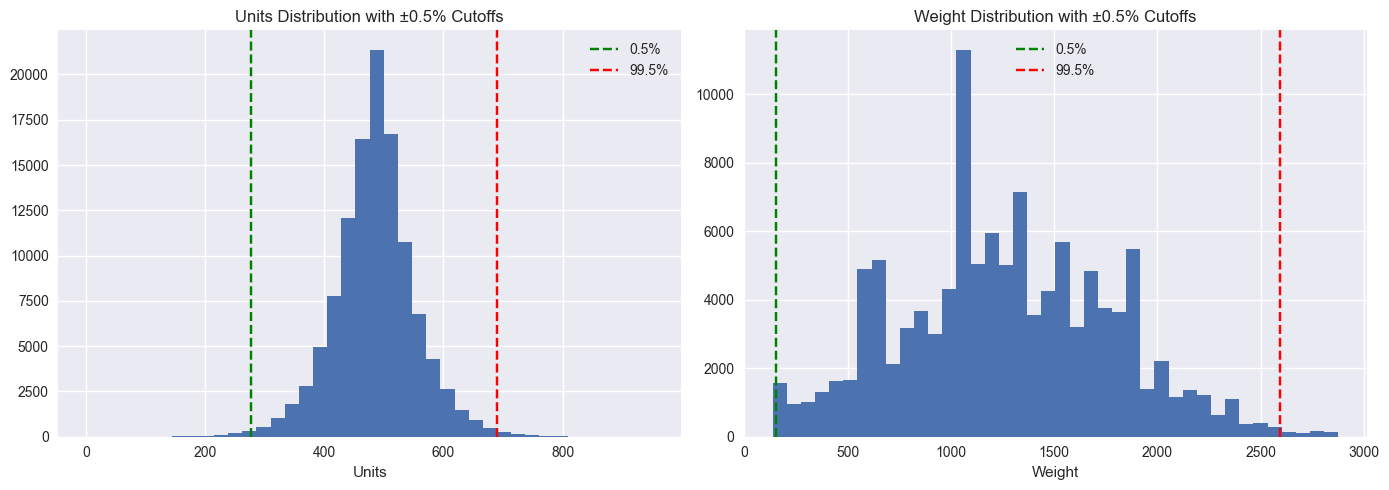

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Istogramma unità
ax[0].hist(df_merge["units"], bins=40)
ax[0].axvline(low_units, color="green", linestyle="--", label="0.5%")
ax[0].axvline(high_units, color="red", linestyle="--", label="99.5%")
ax[0].set_title("Units Distribution with ±0.5% Cutoffs")
ax[0].set_xlabel("Units")
ax[0].legend()

# Istogramma peso
ax[1].hist(df_merge["weight"], bins=40)
ax[1].axvline(low_weight, color="green", linestyle="--", label="0.5%")
ax[1].axvline(high_weight, color="red", linestyle="--", label="99.5%")
ax[1].set_title("Weight Distribution with ±0.5% Cutoffs")
ax[1].set_xlabel("Weight")
ax[1].legend()

plt.tight_layout()
plt.show()

In [60]:
(df_merge["units"] > df_merge["units"].quantile(0.995)).sum()

np.int64(570)

Correlazione

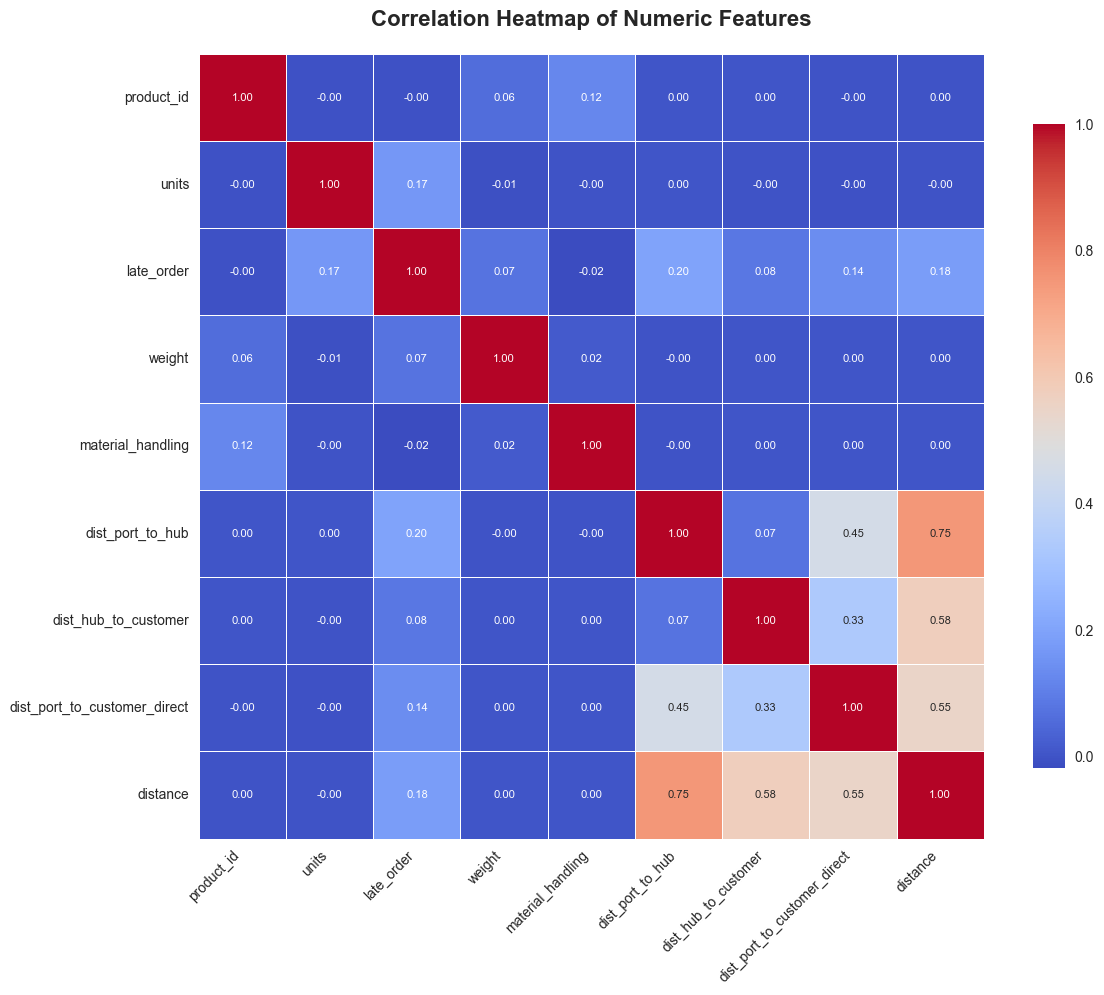

In [61]:
corr = df_merge.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,              
    fmt=".2f",                
    cmap="coolwarm",           
    linewidths=0.5,            
    square=True,               
    cbar_kws={"shrink": 0.8}, 
    annot_kws={"size": 8}      
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=16, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcola il V di Cramer tra due serie categoriali."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [63]:
cats = ["3pl", "origin_port", "logistic_hub", "customer", "customs_procedures", "late_order"]

cramers_matrix = pd.DataFrame(index=cats, columns=cats, dtype=float)

for col1 in cats:
    for col2 in cats:
        cramers_matrix.loc[col1, col2] = cramers_v(df_merge[col1], df_merge[col2])

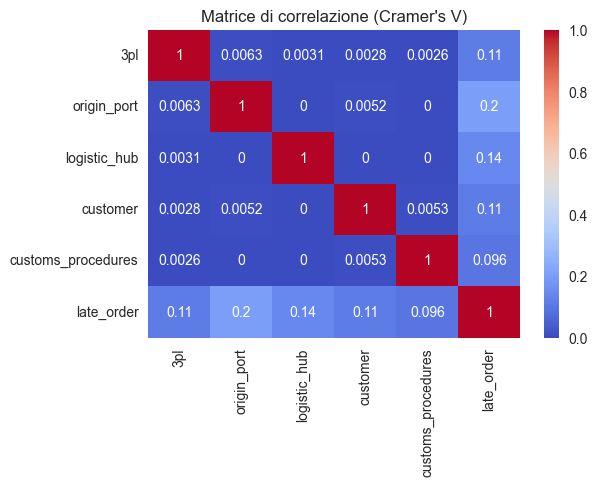

In [64]:
plt.figure(figsize=(6,4))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Matrice di correlazione (Cramer's V)")
plt.show()

In [65]:
import scipy.stats as scp

target = "late_order"
list_vars_vscore = [col for col in cats if col != target]

list_vscores = []

for ii, i in enumerate(list_vars_vscore[:-1]):
    for jj, j in enumerate(list_vars_vscore[ii+1:]):

       
        df_contingency = df_merge.groupby([i, j, 'late_order']) \
                                 .size() \
                                 .unstack() \
                                 .replace(0, np.nan)

    
        df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
        df_contingency = df_contingency.fillna(0).astype(int)


        r, c = df_contingency.shape
        n = df_contingency.sum().sum()

       
        chi2 = scp.chi2_contingency(df_contingency.values, correction=False)[0]

   
        vscore = np.sqrt((chi2 / n) / np.sqrt((r - 1) * (c - 1)))

        list_vscores.append([i, j, 'late_order', vscore])

df_triplets = pd.DataFrame(
    list_vscores,
    columns=['var-x0', 'var-x1', 'var-y', 'v-score']
)

df_triplets = df_triplets.sort_values('v-score', ascending=False)

In [66]:
df_triplets.head(10).style.background_gradient(vmin=0, vmax=.5).format(precision=2)

,var-x0,var-x1,var-y,v-score
6,origin_port,customs_procedures,late_order,0.13
0,3pl,origin_port,late_order,0.13
4,origin_port,logistic_hub,late_order,0.11
3,3pl,customs_procedures,late_order,0.08
5,origin_port,customer,late_order,0.08
8,logistic_hub,customs_procedures,late_order,0.08
1,3pl,logistic_hub,late_order,0.08
2,3pl,customer,late_order,0.05
9,customer,customs_procedures,late_order,0.05
7,logistic_hub,customer,late_order,0.05


In [67]:
df = df_merge.copy()

In [68]:
df["total_weight"] = df["units"] * df_merge["weight"]

In [69]:
df["has_hub"] = df["logistic_hub"].notna().astype(int)

In [70]:
df.head()

,order_id,origin_port,3pl,customs_procedures,logistic_hub,customer,product_id,units,late_order,weight,material_handling,dist_port_to_hub,dist_hub_to_customer,dist_port_to_customer_direct,distance,total_weight,has_hub
0,366c7a3d298f,Rotterdam,v_002,DTP,Venlo,Marseille,1692723,583,True,1778.000,5.000,130.046,902.042,961.635,1032.088,1036574.000,1
1,45f906331e10,Rotterdam,v_004,CRF,Rome,Marseille,1644308,459,False,1088.000,3.000,1269.236,604.022,961.635,1873.258,499392.000,1
2,ac84a6e4af0f,Athens,v_002,CRF,Venlo,Paris,1684170,464,True,505.000,4.000,2029.573,392.925,2101.294,2422.497,234320.000,1
3,f5e98cb29790,Rotterdam,v_004,CRF,Lille,Milan,1620510,678,False,1308.000,4.000,173.964,733.878,797.351,907.843,886824.000,1
4,a9e7c9bee35b,Barcelona,v_002,CRF,Venlo,Berlin,1699372,353,False,1465.000,0.000,1153.418,512.819,1499.697,1666.237,517145.000,1


In [71]:
df['has_hub'].value_counts()

has_hub
1    113109
0      1049
Name: count, dtype: int64

C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\3787869152.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\3787869152.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\3787869152.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\3787869152.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argu

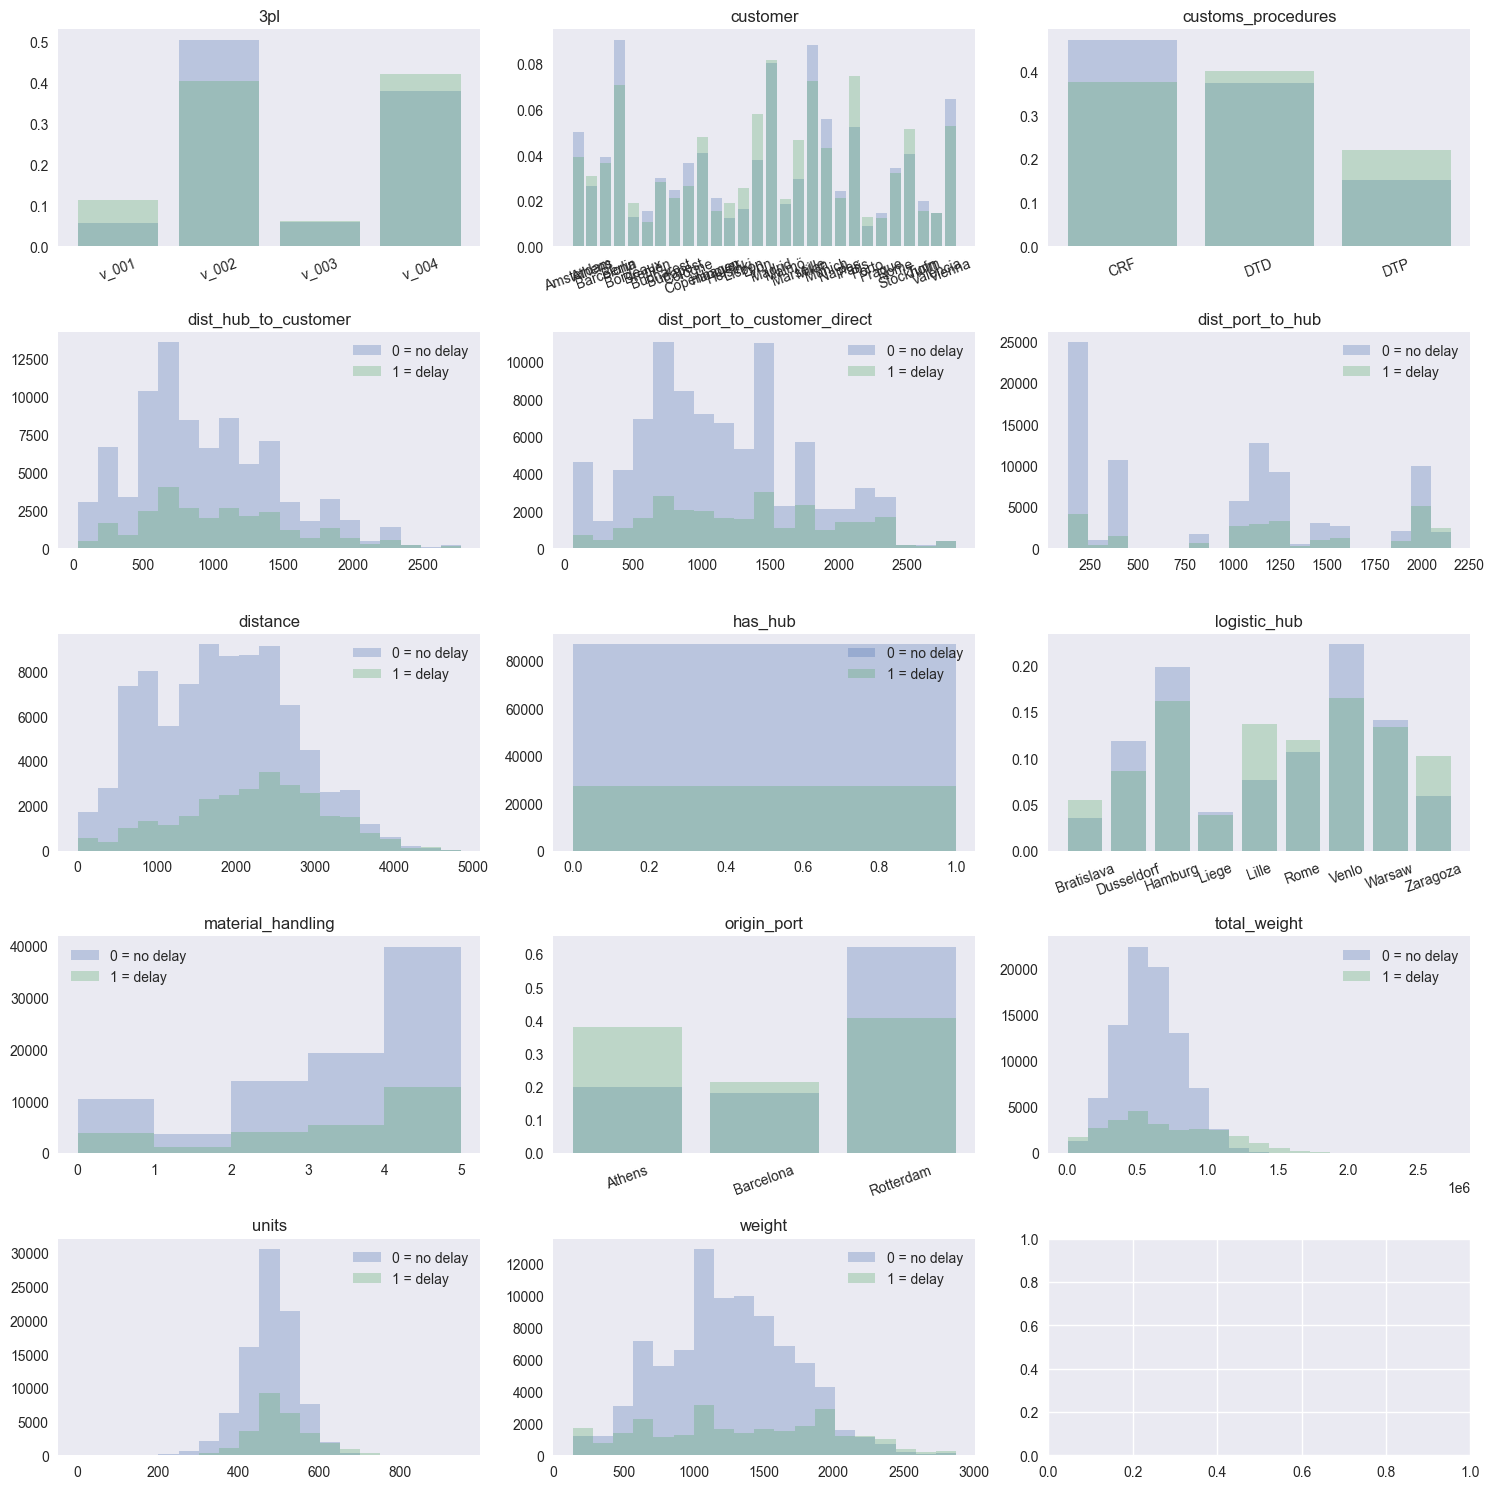

In [72]:
target = "late_order"
df[target] = df[target].astype(int)


id_cols = [c for c in df.columns if "id" in c.lower()]


df = df.drop(columns=id_cols)


num_vars = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
bool_vars = df.select_dtypes(include=["bool"]).columns.tolist()
cat_vars = df.select_dtypes(include=["object", "category"]).columns.tolist()


num_vars = [c for c in num_vars if c != target]
bool_vars = [c for c in bool_vars if c != target]
cat_vars = [c for c in cat_vars if c != target]


all_vars = sorted(num_vars + bool_vars + cat_vars)


n = len(all_vars)
rows = (n // 3) + 1
fig, ax = plt.subplots(nrows=rows, ncols=3, figsize=(15, rows * 3))
ax = ax.flatten()


for kk, col in enumerate(all_vars):

    if df[col].dtype != 'O' and df[col].dtype != 'category':
       
        bins = np.linspace(df[col].min(), df[col].max(), 
                           min(20, df[col].nunique()))

        ax[kk].hist(df.loc[df[target]==0, col],
                    bins=bins, alpha=.3, color='C0', label='0 = no delay')
        
        ax[kk].hist(df.loc[df[target]==1, col],
                    bins=bins, alpha=.3, color='C1', label='1 = delay')
    
    else:
 
        bars_0 = df.loc[df[target]==0, col].value_counts(normalize=True).sort_index()
        bars_1 = df.loc[df[target]==1, col].value_counts(normalize=True).sort_index()

        ax[kk].bar(bars_0.index, bars_0.values, alpha=.3, color='C0')
        ax[kk].bar(bars_1.index, bars_1.values, alpha=.3, color='C1')
        ax[kk].tick_params(axis='x', labelrotation=20)

    ax[kk].set_title(col)
    ax[kk].legend()

    ax[kk].grid()

plt.tight_layout()
plt.show()

C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argu

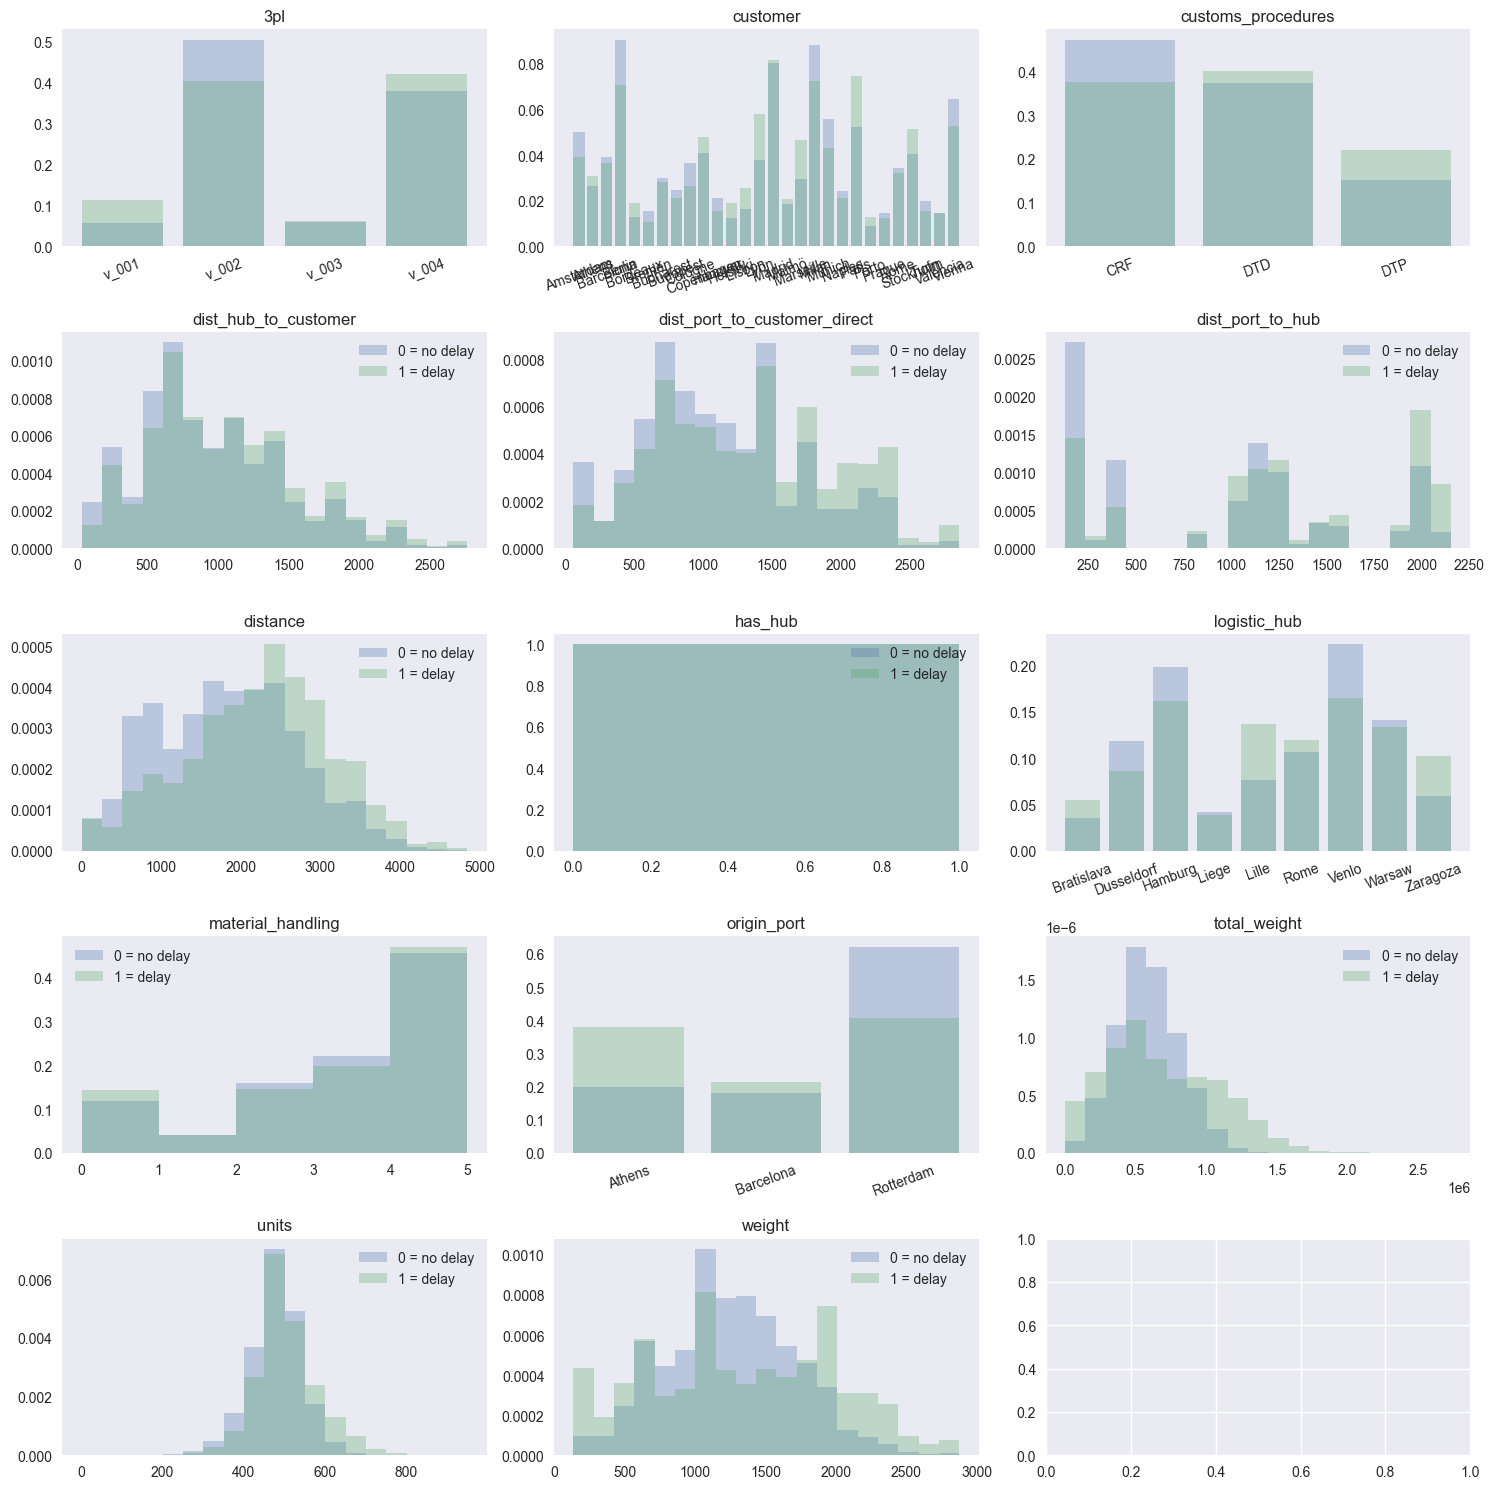

In [73]:
target = "late_order"
df[target] = df[target].astype(int)


id_cols = [c for c in df.columns if "id" in c.lower()]


df = df.drop(columns=id_cols)


num_vars = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
bool_vars = df.select_dtypes(include=["bool"]).columns.tolist()
cat_vars = df.select_dtypes(include=["object", "category"]).columns.tolist()


num_vars = [c for c in num_vars if c != target]
bool_vars = [c for c in bool_vars if c != target]
cat_vars = [c for c in cat_vars if c != target]


all_vars = sorted(num_vars + bool_vars + cat_vars)


n = len(all_vars)
rows = (n // 3) + 1
fig, ax = plt.subplots(nrows=rows, ncols=3, figsize=(15, rows * 3))
ax = ax.flatten()


for kk, col in enumerate(all_vars):

    if df[col].dtype != 'O' and df[col].dtype != 'category':
       
        bins = np.linspace(df[col].min(), df[col].max(), 
                           min(20, df[col].nunique()))

        ax[kk].hist(df.loc[df[target]==0, col],
                    bins=bins, density=True, alpha=.3, color='C0', label='0 = no delay')
        
        ax[kk].hist(df.loc[df[target]==1, col],
                    bins=bins, density=True, alpha=.3, color='C1', label='1 = delay')
    
    else:
 
        bars_0 = df.loc[df[target]==0, col].value_counts(normalize=True).sort_index()
        bars_1 = df.loc[df[target]==1, col].value_counts(normalize=True).sort_index()

        ax[kk].bar(bars_0.index, bars_0.values, alpha=.3, color='C0')
        ax[kk].bar(bars_1.index, bars_1.values, alpha=.3, color='C1')
        ax[kk].tick_params(axis='x', labelrotation=20)

    ax[kk].set_title(col)
    ax[kk].legend()

    ax[kk].grid()

plt.tight_layout()
plt.show()

In [74]:
df_backup = df.copy()

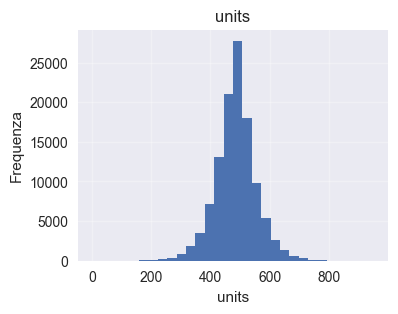

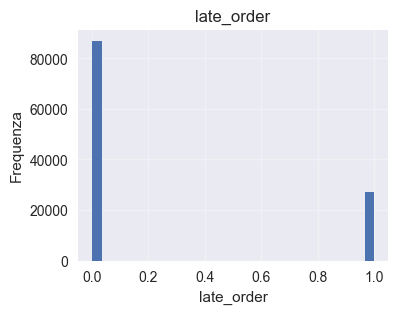

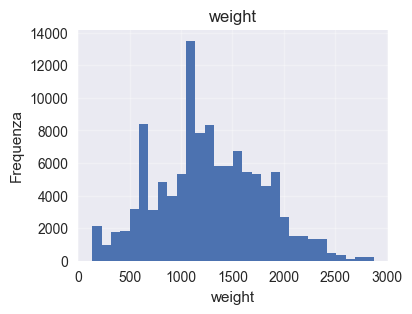

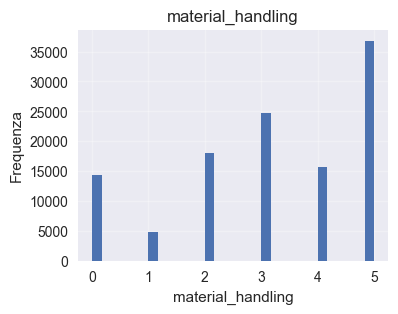

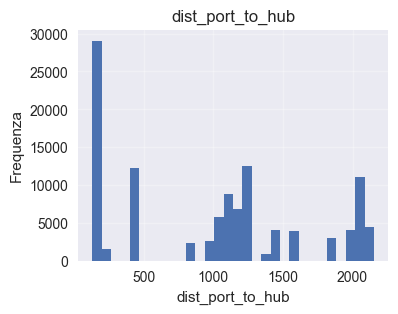

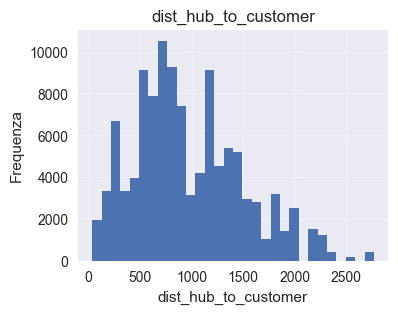

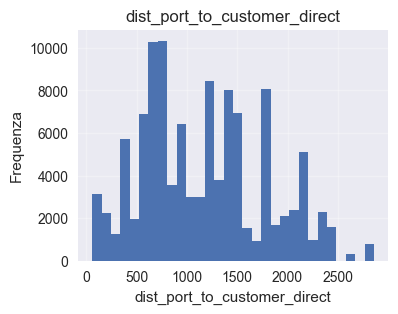

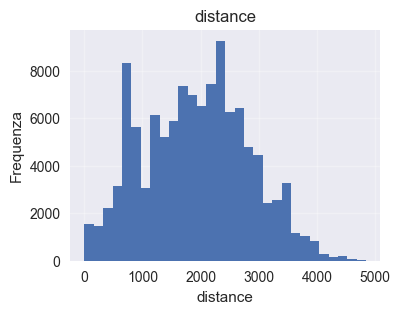

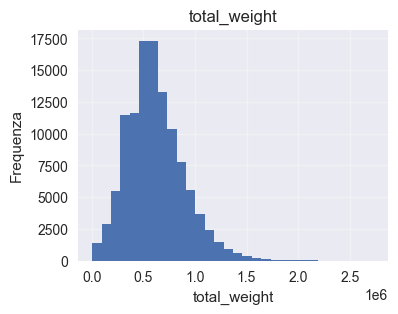

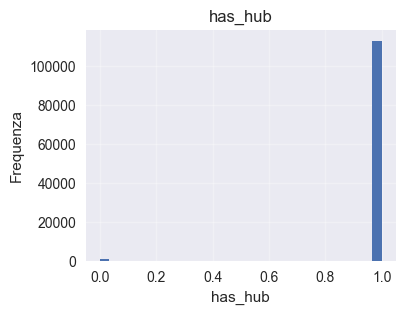

In [75]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(4,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequenza")
    plt.grid(alpha=0.3)
    plt.show()

In [76]:
from optbinning import OptimalBinning

opt_bin_weight = OptimalBinning(
    name="weight",
    dtype="numerical",
    prebinning_method="quantile",
    max_n_bins=7
)

opt_bin_weight.fit(df["weight"], df["late_order"])

splits_array = opt_bin_weight.splits

splits_integer = splits_array.astype(int)

print(splits_integer)

c:\Users\gaiag\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


[ 446  674 1093 1639 1895 2127]


In [77]:
opt_bin_total_units = OptimalBinning(
    name="units",
    dtype="numerical",
    prebinning_method="quantile",
    max_n_bins=4
)

opt_bin_total_units.fit(df["units"], df["late_order"])

splits_array = opt_bin_total_units.splits

splits_integer = splits_array.astype(int)

print(splits_integer)

[472 566 597]


c:\Users\gaiag\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [78]:
opt_bin_total_weight = OptimalBinning(
    name="total_weight",
    dtype="numerical",
    prebinning_method="quantile",
    max_n_bins=4
)

opt_bin_total_weight.fit(df["total_weight"], df["late_order"])

splits_array = opt_bin_total_weight.splits

splits_integer = splits_array.astype(int)

print(splits_integer)

c:\Users\gaiag\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


[ 217224  890329 1110704]


In [79]:
labels_quantile = ['1 - Minimo', '2 - Lieve', '3 - Basso', '4 - Standard', '5 - Elevato', '6 - Rilevante', '7 - Eccessivo']
labels_quantile2 = ['1 - Prossimo', '2 - Raggiungibile', '3 - Medio Raggio', '4 - Lungo Raggio', '5 - Distante', '6 - Estremo']
labels_quantile1 = ['1 - Q', '2 - Q', '3 - Q', '4 - Q']


df["weight_bin"] = pd.cut(
    df["weight"],
    bins=[0, 446, 674, 1093, 1639, 1895, 2127, 3000],
    labels=labels_quantile
    )

df["distance_bin"] = pd.cut(
    df["distance"],
    bins=[-1, 750, 1000, 2000, 2500, 3500, 5000],
    labels=labels_quantile2
    )

df["units_bin"] = pd.cut(
    df["units"], 
    bins=[0, 472, 566, 597, 1000],
    labels=labels_quantile1
)

df["total_weight_bin"] = pd.cut(
    df["total_weight"], 
    bins=[0, 217224, 890329, 1110704, 3000000],
    labels=labels_quantile1
)

C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[kk].legend()
C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\2538890745.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argu

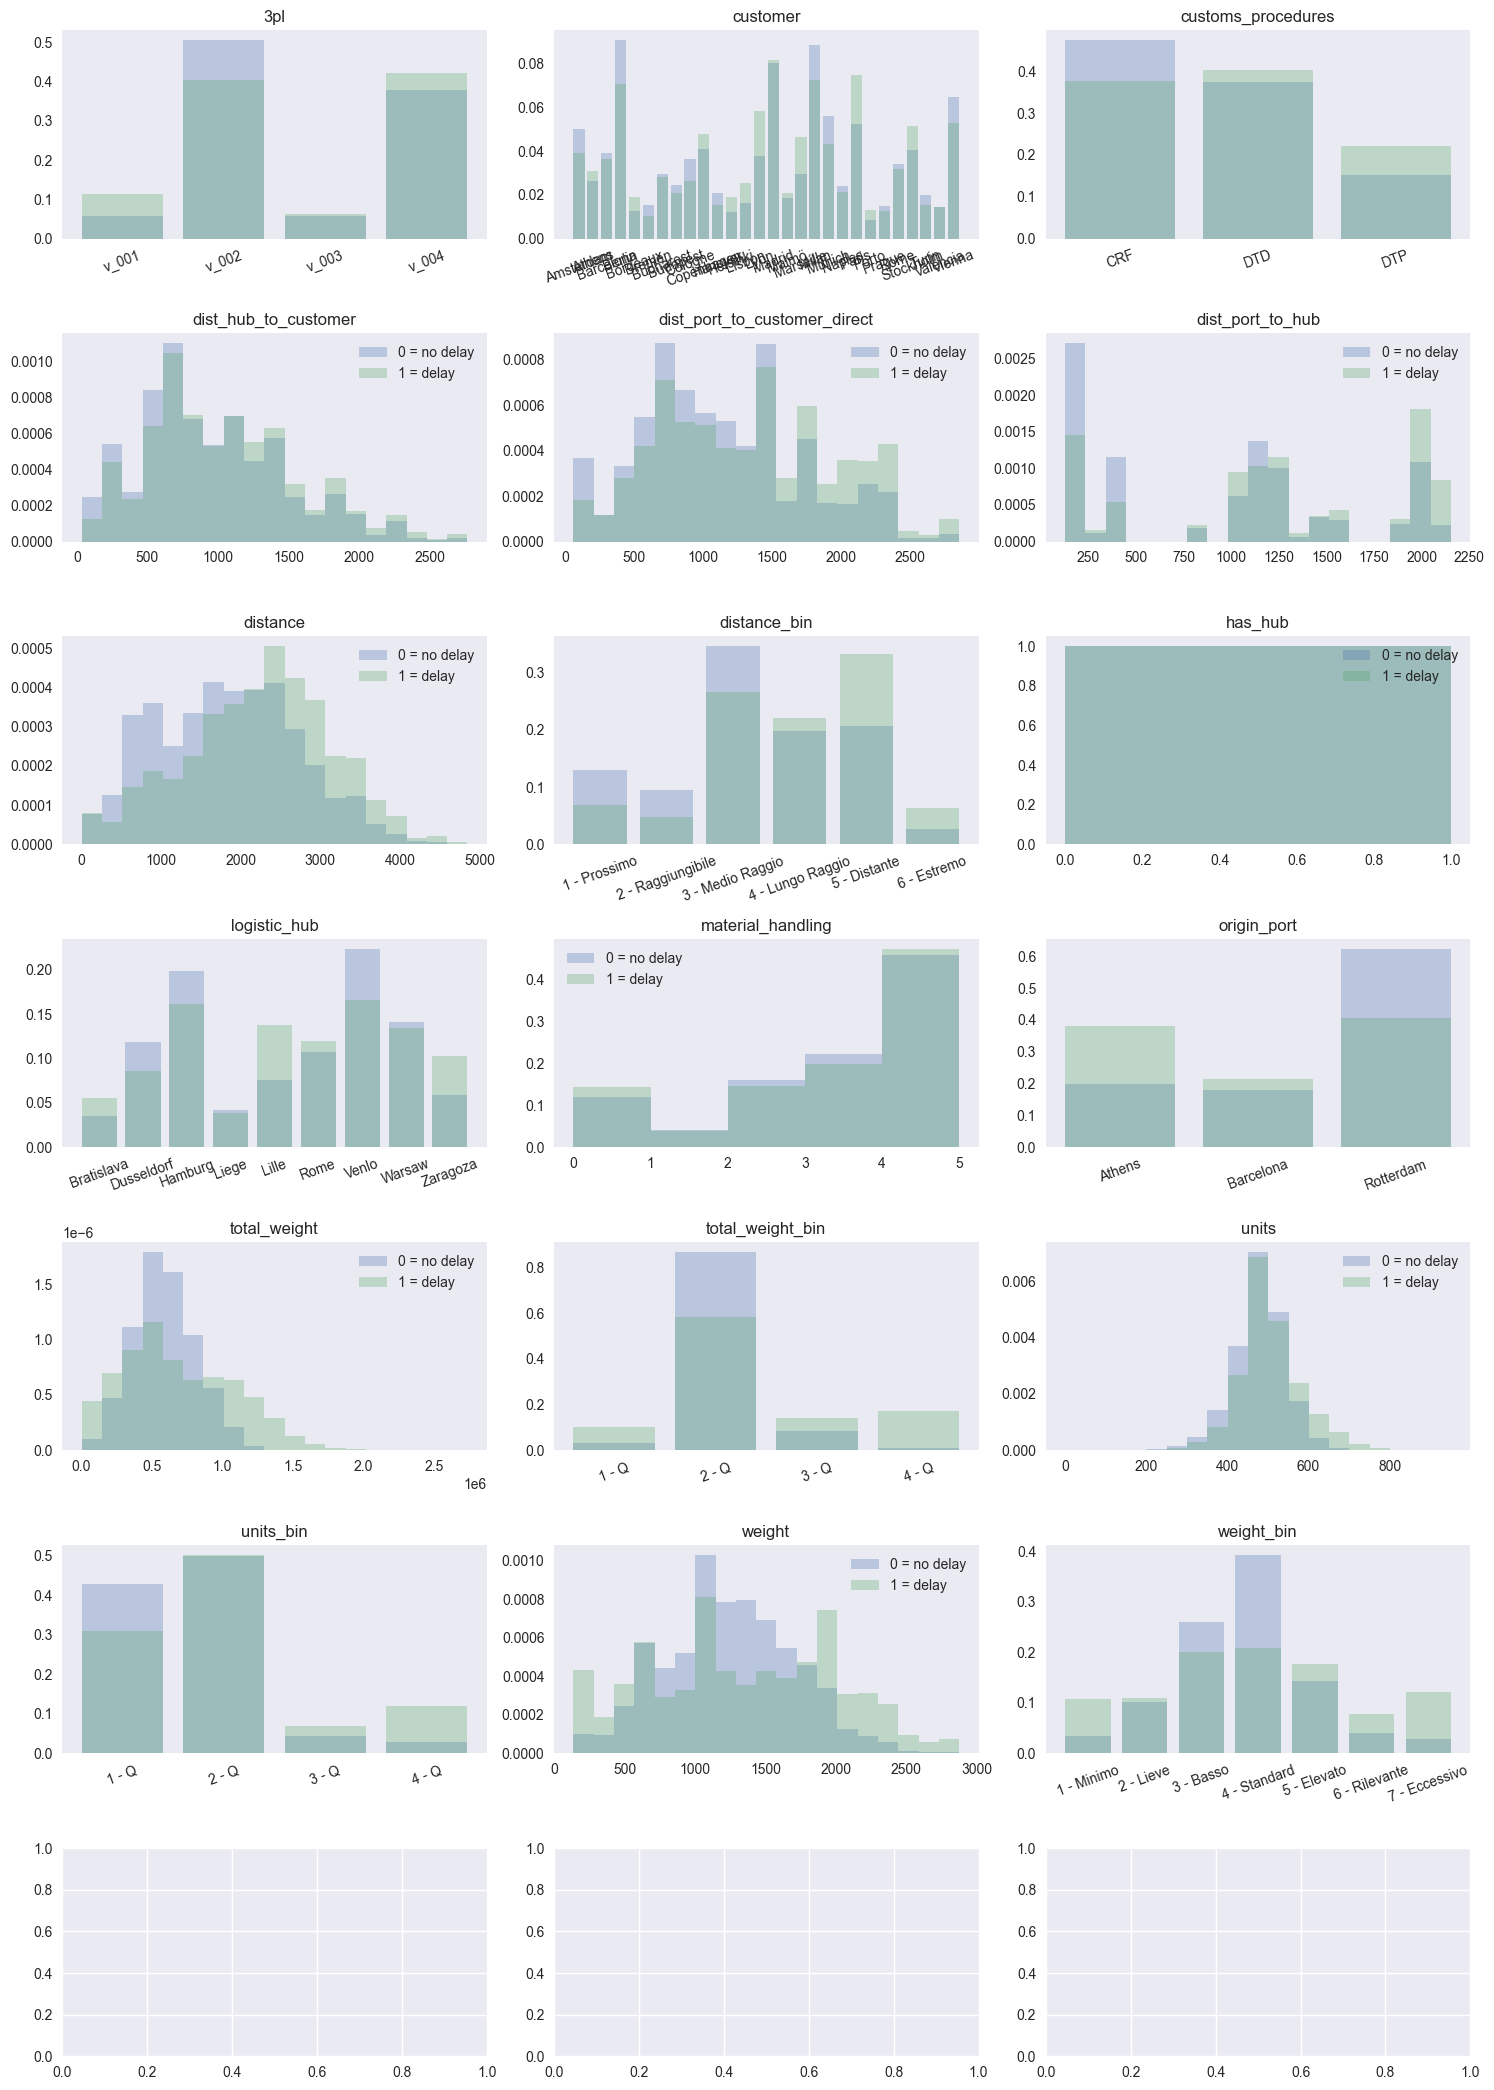

In [80]:
target = "late_order"
df[target] = df[target].astype(int)


id_cols = [c for c in df.columns if "id" in c.lower()]


df = df.drop(columns=id_cols)


num_vars = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
bool_vars = df.select_dtypes(include=["bool"]).columns.tolist()
cat_vars = df.select_dtypes(include=["object", "category"]).columns.tolist()


num_vars = [c for c in num_vars if c != target]
bool_vars = [c for c in bool_vars if c != target]
cat_vars = [c for c in cat_vars if c != target]


all_vars = sorted(num_vars + bool_vars + cat_vars)


n = len(all_vars)
rows = (n // 3) + 1
fig, ax = plt.subplots(nrows=rows, ncols=3, figsize=(15, rows * 3))
ax = ax.flatten()


for kk, col in enumerate(all_vars):

    if df[col].dtype != 'O' and df[col].dtype != 'category':
       
        bins = np.linspace(df[col].min(), df[col].max(), 
                           min(20, df[col].nunique()))

        ax[kk].hist(df.loc[df[target]==0, col],
                    bins=bins, density=True, alpha=.3, color='C0', label='0 = no delay')
        
        ax[kk].hist(df.loc[df[target]==1, col],
                    bins=bins, density=True, alpha=.3, color='C1', label='1 = delay')
    
    else:
 
        bars_0 = df.loc[df[target]==0, col].value_counts(normalize=True).sort_index()
        bars_1 = df.loc[df[target]==1, col].value_counts(normalize=True).sort_index()

        ax[kk].bar(bars_0.index, bars_0.values, alpha=.3, color='C0')
        ax[kk].bar(bars_1.index, bars_1.values, alpha=.3, color='C1')
        ax[kk].tick_params(axis='x', labelrotation=20)

    ax[kk].set_title(col)
    ax[kk].legend()

    ax[kk].grid()

plt.tight_layout()
plt.show()

In [81]:
target = "late_order"

bin_cols = [col for col in df.columns if col.endswith("_bin")] + [target]

cramers_matrix = pd.DataFrame(index=bin_cols, columns=bin_cols, dtype=float)

for col1 in bin_cols:
    for col2 in bin_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

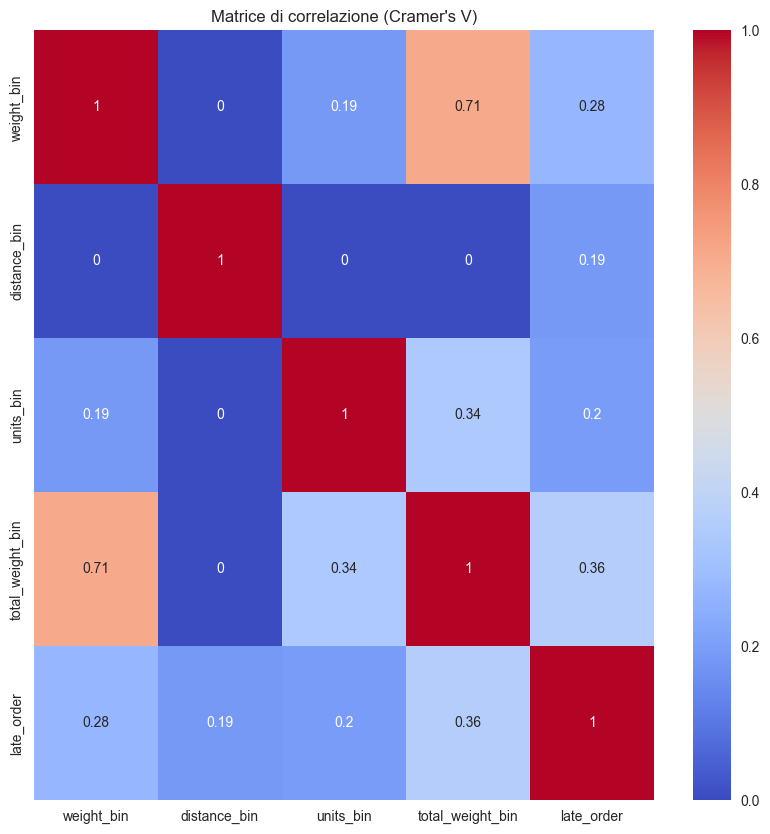

In [82]:
plt.figure(figsize=(10,10))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Matrice di correlazione (Cramer's V)")
plt.show()

In [83]:
df['product_id'] = df_merge['product_id']
df['order_id'] = df_merge['order_id']

In [84]:
df_quality_pulito = df
nome_file_csv = 'dati_processati.csv'

df_quality_pulito.to_csv(nome_file_csv, index=False)

print(f"DataFrame esportato con successo come: {nome_file_csv}")

DataFrame esportato con successo come: dati_processati.csv


In [85]:
df_reg = df.copy()

In [86]:
df_outliers = df.copy()

In [87]:
df_quality_outliers = df
nome_file_csv = 'dati_outliers.csv'

df_quality_pulito.to_csv(nome_file_csv, index=False)

print(f"DataFrame esportato con successo come: {nome_file_csv}")

DataFrame esportato con successo come: dati_outliers.csv


### Feature Engineering

In [88]:
import pandas as pd

city_to_country = {
    "Rotterdam": "Netherlands", "Athens": "Greece", "Barcelona": "Spain",
    "Berlin": "Germany", "Milan": "Italy", "Madrid": "Spain",
    "Vienna": "Austria", "Paris": "France", "Munich": "Germany",
    "Amsterdam": "Netherlands", "Stockholm": "Sweden", "Copenhagen": "Denmark",
    "Lyon": "France", "Cologne": "Germany", "Rome": "Italy",
    "Marseille" : "France", "Bucharest" : "Romania", "Budapest" : "Hungary",
    "Naples" : "Italy", "Hanover": "Germany", "Malmö": "Sweden",
    "Turin": "Italy", "Lisbon": "Portugal", "Valencia": "Spain",
    "Prague": "Czechia", "Bordeaux": "France", "Bremen": "Germany",
    "Helsinki": "Finland", "Porto": "Portugal", "Venlo": "Netherlands",
    "Hamburg": "Germany", "Warsaw": "Poland", "Dusseldorf": "Germany",
    "Lille": "France", "Zaragoza": "Spain", "Liege": "Belgium",
    "Bratislava": "Slovakia", "Rotterdam": "Netherlands"
}

df["hub_country"] = df["logistic_hub"].map(city_to_country)
df["customer_country"] = df["customer"].map(city_to_country)
df["origin_country"] = df["origin_port"].map(city_to_country)

# --- 3. CREAZIONE NUOVA FEATURE: ROTTA DOMESTICA ---
# Flag binario: 1 se la nazione di partenza è uguale a quella di arrivo, 0 se internazionale
df['same_country'] = (df['hub_country'] == df['customer_country']).astype(int)

# 2. Peso x Distanza (Fattore di Carico)
# Matematicamente equivale ai "Ton-Kilometers". Più è alto, più è difficile la spedizione.
df['weight_x_distance'] = df['total_weight'] * df['distance']

# 3. Rotta x Trasportatore
# Definiamo la "Rotta" in modo intelligente usando i Paesi che hai mappato
# (es. Da Rotterdam a Italy è meglio di Rotterdam a Milan per generalizzare)
df['route_geo'] = df['origin_port'] + "_to_" + df['customer']

# Creiamo l'interazione finale: Quel trasportatore su quella specifica rotta
df['route_x_upl'] = df['route_geo'] + "_" + df['3pl']

# --- VISTA RISULTATO ---
print("Nuove Feature create:")


Nuove Feature create:


In [89]:
df["weight_class"] = pd.qcut(df["weight"], q=4, labels=[
    "W1_Light",
    "W2_Medium",
    "W3_Heavy",
    "W4_ExtraHeavy"
])

df["weight_risk_category"] = df["weight_class"].astype(str) + "_" + df["material_handling"].astype(str)

df["weight_risk_category"].value_counts()   #24 categorie

weight_risk_category
W1_Light_5.0         10849
W2_Medium_3.0         9275
W3_Heavy_5.0          9008
W4_ExtraHeavy_5.0     8651
W2_Medium_5.0         8335
W4_ExtraHeavy_4.0     6604
W1_Light_2.0          5774
W1_Light_3.0          5744
W3_Heavy_3.0          5081
W3_Heavy_4.0          4739
W4_ExtraHeavy_3.0     4570
W4_ExtraHeavy_2.0     4256
W2_Medium_0.0         4178
W3_Heavy_0.0          4116
W3_Heavy_2.0          4025
W2_Medium_2.0         3882
W1_Light_0.0          3252
W4_ExtraHeavy_0.0     2760
W1_Light_4.0          2245
W2_Medium_4.0         2081
W4_ExtraHeavy_1.0     1692
W3_Heavy_1.0          1559
W2_Medium_1.0          787
W1_Light_1.0           695
Name: count, dtype: int64

In [90]:
df["3pl_customs"] = df["3pl"] + "_" + df["customs_procedures"]
print(df["3pl_customs"])

0         v_002_DTP
1         v_004_CRF
2         v_002_CRF
3         v_004_CRF
4         v_002_CRF
            ...    
114271    v_002_CRF
114272    v_004_DTD
114273    v_002_DTP
114274    v_003_DTD
114275    v_002_DTD
Name: 3pl_customs, Length: 114158, dtype: object


In [91]:
# Calcoliamo il peso medio per ogni categoria di material_handling
# Usa .transform per mantenere la stessa lunghezza del dataframe originale
mean_weight_by_risk = df.groupby('material_handling')['weight'].transform('mean')

# Feature: Ratio (Rapporto)
# Se > 1: Il pacco è più pesante della media della sua categoria 
df['weight_vs_risk_avg'] = df['weight'] / mean_weight_by_risk

print("Esempio: Un valore di 1.5 significa che il pacco pesa il 50% in più della media per quel tipo di rischio.")

Esempio: Un valore di 1.5 significa che il pacco pesa il 50% in più della media per quel tipo di rischio.


In [92]:
df.head()

,origin_port,3pl,customs_procedures,logistic_hub,customer,units,late_order,weight,material_handling,dist_port_to_hub,...,customer_country,origin_country,same_country,weight_x_distance,route_geo,route_x_upl,weight_class,weight_risk_category,3pl_customs,weight_vs_risk_avg
0,Rotterdam,v_002,DTP,Venlo,Marseille,583,1,1778.000,5.000,130.046,...,France,Netherlands,0,1069835482.855,Rotterdam_to_Marseille,Rotterdam_to_Marseille_v_002,W4_ExtraHeavy,W4_ExtraHeavy_5.0,v_002_DTP,1.439
1,Rotterdam,v_004,CRF,Rome,Marseille,459,0,1088.000,3.000,1269.236,...,France,Netherlands,0,935490109.075,Rotterdam_to_Marseille,Rotterdam_to_Marseille_v_004,W2_Medium,W2_Medium_3.0,v_004_CRF,0.885
2,Athens,v_002,CRF,Venlo,Paris,464,1,505.000,4.000,2029.573,...,France,Greece,0,567639614.200,Athens_to_Paris,Athens_to_Paris_v_002,W1_Light,W1_Light_4.0,v_002_CRF,0.347
3,Rotterdam,v_004,CRF,Lille,Milan,678,0,1308.000,4.000,173.964,...,Italy,Netherlands,0,805096783.267,Rotterdam_to_Milan,Rotterdam_to_Milan_v_004,W3_Heavy,W3_Heavy_4.0,v_004_CRF,0.899
4,Barcelona,v_002,CRF,Venlo,Berlin,353,0,1465.000,0.000,1153.418,...,Germany,Spain,0,861685926.507,Barcelona_to_Berlin,Barcelona_to_Berlin_v_002,W3_Heavy,W3_Heavy_0.0,v_002_CRF,1.178


In [93]:
df["origin_country"].unique()

array(['Netherlands', 'Greece', 'Spain'], dtype=object)

In [94]:
df["customer_country"].unique()

array(['France', 'Italy', 'Germany', 'Czechia', 'Spain', 'Greece',
       'Portugal', 'Austria', 'Sweden', 'Netherlands', 'Hungary',
       'Finland', 'Denmark', 'Romania'], dtype=object)

In [95]:
df["hub_country"].unique()

array(['Netherlands', 'Italy', 'France', 'Slovakia', 'Poland', nan,
       'Germany', 'Belgium', 'Spain'], dtype=object)

In [96]:
df["logistic_hub"] = df["logistic_hub"].fillna("NoHub")
df["hub_country"] = df["hub_country"].fillna("NoHub")

In [97]:
lpi_infra = {
    "Netherlands": 4.02,
    "Greece": 3.20,
    "Spain": 3.83,
    "France": 3.84,
    "Italy": 3.74,
    "Germany": 4.20,
    "Czechia": 3.68,
    "Portugal": 3.56,
    "Austria": 4.03,
    "Sweden": 4.05,
    "Hungary": 3.42,
    "Finland": 3.97,
    "Denmark": 3.99,
    "Romania": 3.12,
    "Slovakia": 3.03,
    "Poland": 3.54,
    "Belgium": 4.04
}

In [98]:
lpi_infra["NoHub"] = np.nan

In [99]:
df["origin_lpi"] = df["origin_country"].map(lpi_infra)
df["customer_lpi"] = df["customer_country"].map(lpi_infra)
df["hub_lpi"] = df["hub_country"].map(lpi_infra)

In [100]:
num_cols = ['units', 'weight', 'dist_port_to_hub', 'dist_hub_to_customer',
       'dist_port_to_customer_direct', 'distance', 'total_weight']

In [101]:
cat_cols = ['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer']

In [102]:
for col in num_cols:
    df[col + "_2"] = df[col] ** 2


In [103]:
for col in num_cols:
    df[col + "_3"] = df[col] ** 3

In [104]:
gruppi = {
    "origin_port": {
        "dist_port_to_hub": ["mean", "std"],
        "dist_port_to_customer_direct": ["mean", "std"],
        "distance": ["mean", "std"]
    },

    "3pl": {
        "dist_port_to_hub": ["mean"],
        "distance": ["mean", "std"]
    },

    "customs_procedures": {
        "distance": ["mean", "std"]
    },

    "logistic_hub": {
        "dist_port_to_hub": ["mean", "std"],
        "dist_hub_to_customer": ["mean", "std"]
    },

    "customer": {
        "dist_hub_to_customer": ["mean", "std"],
        "dist_port_to_customer_direct": ["mean", "std"],
        "distance": ["mean", "std"]
    }
}

# CREAZIONE AUTOMATICA DELLE VARIABILI PER GRUPPO
for cat, vars_dict in gruppi.items():
    for num_var, stats in vars_dict.items():

        for stat in stats:

            nuova_colonna = f"{cat}_{num_var}_{stat}"

            df[nuova_colonna] = df.groupby(cat)[num_var].transform(stat)

In [105]:
df['origin_port'] = df['origin_port'].fillna('Unknown').astype(str)
df['logistic_hub'] = df['logistic_hub'].fillna('Direct').astype(str)

df['customer'] = df['customer'].fillna('Unknown').astype(str)


# Livello 1: Porto -> Hub
df['origin_port_TO_logistic_hub'] = df['origin_port'] + '_' + df['logistic_hub']

# Livello 2: Hub -> Cliente
df['logistic_hub_TO_city_customer'] = df['logistic_hub'] + '_' + df['customer']

# Livello 3: Porto -> Hub -> Cliente
df['FULL_origin_port_TO_logistic_hub_TO_city_customer'] = df['origin_port'] + '' + df['logistic_hub'] + '' + df['customer']



numerical_cols = ['weight', 'units'] 

grouping_cols = ['origin_port_TO_logistic_hub','logistic_hub_TO_city_customer','FULL_origin_port_TO_logistic_hub_TO_city_customer']

for group_col in grouping_cols:
    for num_col in numerical_cols:
        
        mean_col_name = f'mean_{num_col}by{group_col}'
        df[mean_col_name] = df.groupby(group_col)[num_col].transform('mean')
        
        std_col_name = f'std_{num_col}by{group_col}'
        df[std_col_name] = df.groupby(group_col)[num_col].transform('std')
        
        zscore_col_name = f'zscore_{num_col}by{group_col}'
        
        df[zscore_col_name] = (df[num_col] - df[mean_col_name]) / df[std_col_name]
        
        df[zscore_col_name] = df[zscore_col_name].fillna(0)

In [106]:
df.shape

(114158, 91)

In [107]:
corr = df.corr(numeric_only=True)

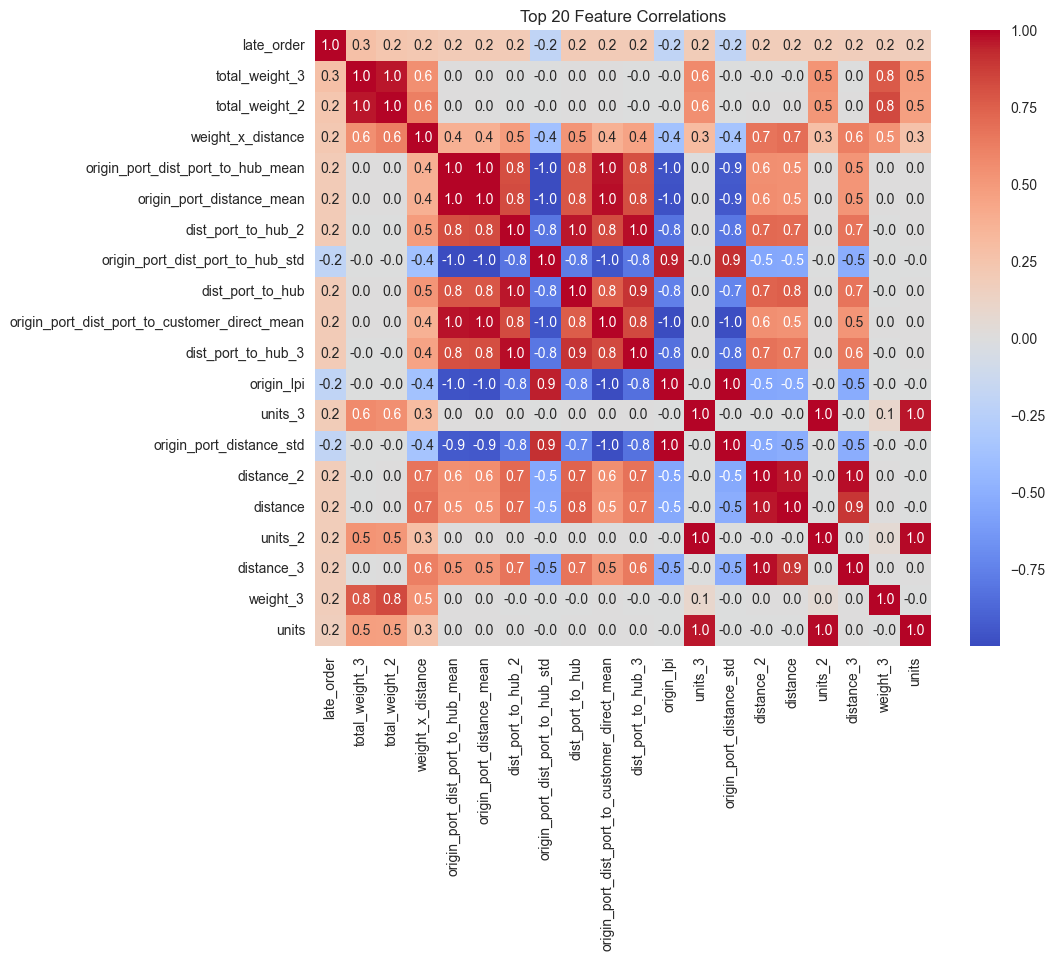

In [108]:
target_corr = corr["late_order"].abs().sort_values(ascending=False)

top_features = target_corr.head(20).index 

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr.loc[top_features, top_features],
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    square=True,
    
)
plt.title("Top 20 Feature Correlations")
plt.show()

In [109]:
cats = ['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer', 'hub_country', 'customer_country', 'origin_country',
       'route_geo', 'route_x_upl', 'weight_risk_category',
       '3pl_customs', 'origin_port_TO_logistic_hub',
       'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer','late_order']

cramers_matrix = pd.DataFrame(index=cats, columns=cats, dtype=float)

for col1 in cats:
    for col2 in cats:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

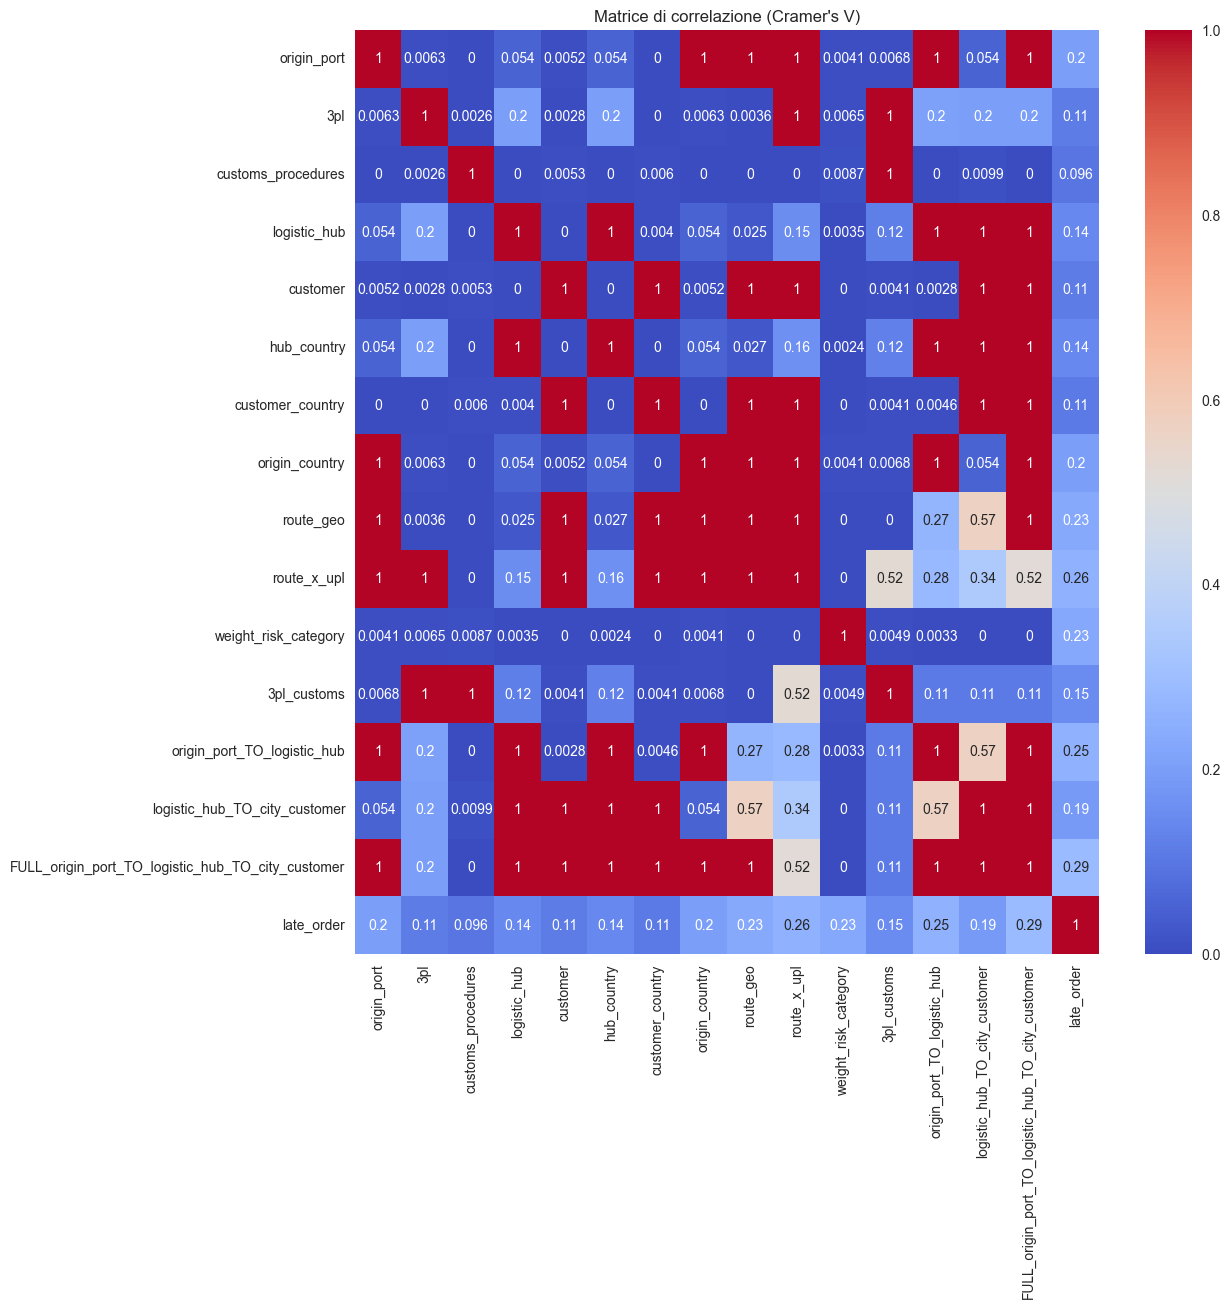

In [110]:
plt.figure(figsize=(12,12))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Matrice di correlazione (Cramer's V)")
plt.show()

In [111]:
df_quality_pulito = df
nome_file_csv = 'dati_processati.csv'

df_quality_pulito.to_csv(nome_file_csv, index=False)

print(f"DataFrame esportato con successo come: {nome_file_csv}")

DataFrame esportato con successo come: dati_processati.csv


In [112]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [113]:
num_cols = ['same_country', 'weight_x_distance', 'weight_vs_risk_avg',
       'origin_lpi', 'customer_lpi', 'hub_lpi', 'units_2', 'weight_2',
       'dist_port_to_hub_2', 'dist_hub_to_customer_2',
       'dist_port_to_customer_direct_2', 'distance_2', 'total_weight_2',
       'units_3', 'weight_3', 'dist_port_to_hub_3', 'dist_hub_to_customer_3',
       'dist_port_to_customer_direct_3', 'distance_3', 'total_weight_3',
       'origin_port_dist_port_to_hub_mean', 'origin_port_dist_port_to_hub_std',
       'origin_port_dist_port_to_customer_direct_mean',
       'origin_port_dist_port_to_customer_direct_std',
       'origin_port_distance_mean', 'origin_port_distance_std',
       '3pl_dist_port_to_hub_mean', '3pl_distance_mean', '3pl_distance_std',
       'customs_procedures_distance_mean', 'customs_procedures_distance_std',
       'logistic_hub_dist_port_to_hub_mean',
       'logistic_hub_dist_port_to_hub_std',
       'logistic_hub_dist_hub_to_customer_mean',
       'logistic_hub_dist_hub_to_customer_std',
       'customer_dist_hub_to_customer_mean',
       'customer_dist_hub_to_customer_std',
       'customer_dist_port_to_customer_direct_mean',
       'customer_dist_port_to_customer_direct_std', 'customer_distance_mean',
       'customer_distance_std', 'mean_weightbyorigin_port_TO_logistic_hub',
       'std_weightbyorigin_port_TO_logistic_hub',
       'zscore_weightbyorigin_port_TO_logistic_hub',
       'mean_unitsbyorigin_port_TO_logistic_hub',
       'std_unitsbyorigin_port_TO_logistic_hub',
       'zscore_unitsbyorigin_port_TO_logistic_hub',
       'mean_weightbylogistic_hub_TO_city_customer',
       'std_weightbylogistic_hub_TO_city_customer',
       'zscore_weightbylogistic_hub_TO_city_customer',
       'mean_unitsbylogistic_hub_TO_city_customer',
       'std_unitsbylogistic_hub_TO_city_customer',
       'zscore_unitsbylogistic_hub_TO_city_customer',
       'mean_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'std_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'mean_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'std_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer', 'late_order']

In [114]:
df.isna().sum()

origin_port                                                         0
3pl                                                                 0
customs_procedures                                                  0
logistic_hub                                                        0
customer                                                            0
                                                                   ..
std_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer       8
zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer    0
mean_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer       0
std_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer        8
zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer     0
Length: 91, dtype: int64

In [115]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

In [116]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['late_order', 'product_id', 'order_id'])
y = df['late_order']
X_train_1, X_val, y_train_1, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [117]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_1, y_train_1, test_size=0.2, random_state=42)

In [118]:
colonne_categoriche = ['origin_port', '3pl', 'customs_procedures', 'customer', 'weight_bin', 'distance_bin', 'units_bin', 'total_weight_bin']

df_log = pd.get_dummies(
    df,
    columns=colonne_categoriche,
    drop_first=True
)

### Varianza

In [119]:
num_cols_stable = [c for c in num_cols if not c.startswith("zscore_")]

cv_num_stable = df[num_cols_stable].std() / (df[num_cols_stable].max() - df[num_cols_stable].min())
cv_num_stable = cv_num_stable.sort_values(ascending=True)
cv_num_stable


mean_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer    0.026
total_weight_3                                                   0.028
mean_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer   0.036
std_weightbyorigin_port_TO_logistic_hub                          0.037
std_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer    0.040
std_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer     0.048
total_weight_2                                                   0.055
mean_weightbylogistic_hub_TO_city_customer                       0.055
std_unitsbyorigin_port_TO_logistic_hub                           0.057
std_weightbylogistic_hub_TO_city_customer                        0.059
mean_weightbyorigin_port_TO_logistic_hub                         0.059
mean_unitsbylogistic_hub_TO_city_customer                        0.059
units_3                                                          0.060
std_unitsbylogistic_hub_TO_city_customer                         0.067
units_

In [120]:
var_zscore = [c for c in num_cols if c.startswith("zscore_")]
var_zscore = df[var_zscore].var()
var_zscore = var_zscore.sort_values(ascending=True)
var_zscore

zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer    0.993
zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer   0.993
zscore_unitsbylogistic_hub_TO_city_customer                        0.998
zscore_weightbylogistic_hub_TO_city_customer                       0.998
zscore_unitsbyorigin_port_TO_logistic_hub                          1.000
zscore_weightbyorigin_port_TO_logistic_hub                         1.000
dtype: float64

In [121]:
df.select_dtypes(include=["object", "category"]).columns

Index(['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'weight_bin', 'distance_bin', 'units_bin', 'total_weight_bin',
       'order_id', 'hub_country', 'customer_country', 'origin_country',
       'route_geo', 'route_x_upl', 'weight_class', 'weight_risk_category',
       '3pl_customs', 'origin_port_TO_logistic_hub',
       'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer'],
      dtype='object')

In [122]:

from scipy.stats import entropy

cat_cols = ['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'weight_bin', 'distance_bin', 'units_bin', 'total_weight_bin',
       'order_id', 'hub_country', 'customer_country', 'origin_country',
       'route_geo', 'route_x_upl', 'weight_class', 'weight_risk_category',
       '3pl_customs', 'origin_port_TO_logistic_hub',
       'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer', 'same_country']

entropy_cat_norm = {}

for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    H = entropy(freq, base=2)
    Hmax = np.log2(len(freq))  # massima entropia
    entropy_cat_norm[col] = H / Hmax  # normalizzazione 0–1

entropy_cat_norm = pd.Series(entropy_cat_norm)
entropy_cat_norm_sorted = entropy_cat_norm.sort_values(ascending=True)
entropy_cat_norm_sorted

same_country                                        0.504
total_weight_bin                                    0.511
units_bin                                           0.730
3pl                                                 0.774
3pl_customs                                         0.845
weight_bin                                          0.865
hub_country                                         0.866
customer_country                                    0.874
origin_country                                      0.889
origin_port                                         0.889
route_x_upl                                         0.895
distance_bin                                        0.895
logistic_hub                                        0.912
origin_port_TO_logistic_hub                         0.912
FULL_origin_port_TO_logistic_hub_TO_city_customer   0.931
logistic_hub_TO_city_customer                       0.933
route_geo                                           0.934
customs_proced

In [123]:
low_cv_features = cv_num_stable[cv_num_stable < 0.20].index.tolist()
low_cv_features


['mean_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
 'total_weight_3',
 'mean_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
 'std_weightbyorigin_port_TO_logistic_hub',
 'std_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
 'std_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
 'total_weight_2',
 'mean_weightbylogistic_hub_TO_city_customer',
 'std_unitsbyorigin_port_TO_logistic_hub',
 'std_weightbylogistic_hub_TO_city_customer',
 'mean_weightbyorigin_port_TO_logistic_hub',
 'mean_unitsbylogistic_hub_TO_city_customer',
 'units_3',
 'std_unitsbylogistic_hub_TO_city_customer',
 'units_2',
 'weight_x_distance',
 'mean_unitsbyorigin_port_TO_logistic_hub',
 'distance_3',
 'dist_hub_to_customer_3',
 'weight_3',
 'distance_2',
 'dist_hub_to_customer_2',
 'weight_2',
 'dist_port_to_customer_direct_3',
 'weight_vs_risk_avg',
 'dist_port_to_customer_direct_2']

In [124]:
df_copy = df.copy()

In [125]:
df = df.drop(columns=low_cv_features)

### Collinearità

In [126]:
distance_cols = [
    c for c in df.columns
    if (("dist" in c.lower() or "distance" in c.lower())
        and not c.endswith("_bin"))
]

In [127]:
distance_cols = ['dist_port_to_hub',
 'dist_hub_to_customer',
 'dist_port_to_customer_direct',
 'distance',
 'dist_port_to_hub_2',
 'dist_port_to_hub_3',
 'origin_port_dist_port_to_hub_mean',
 'origin_port_dist_port_to_hub_std',
 'origin_port_dist_port_to_customer_direct_mean',
 'origin_port_dist_port_to_customer_direct_std',
 'origin_port_distance_mean',
 'origin_port_distance_std']

In [128]:
corr_distance = df[distance_cols + ["late_order"]].corr()

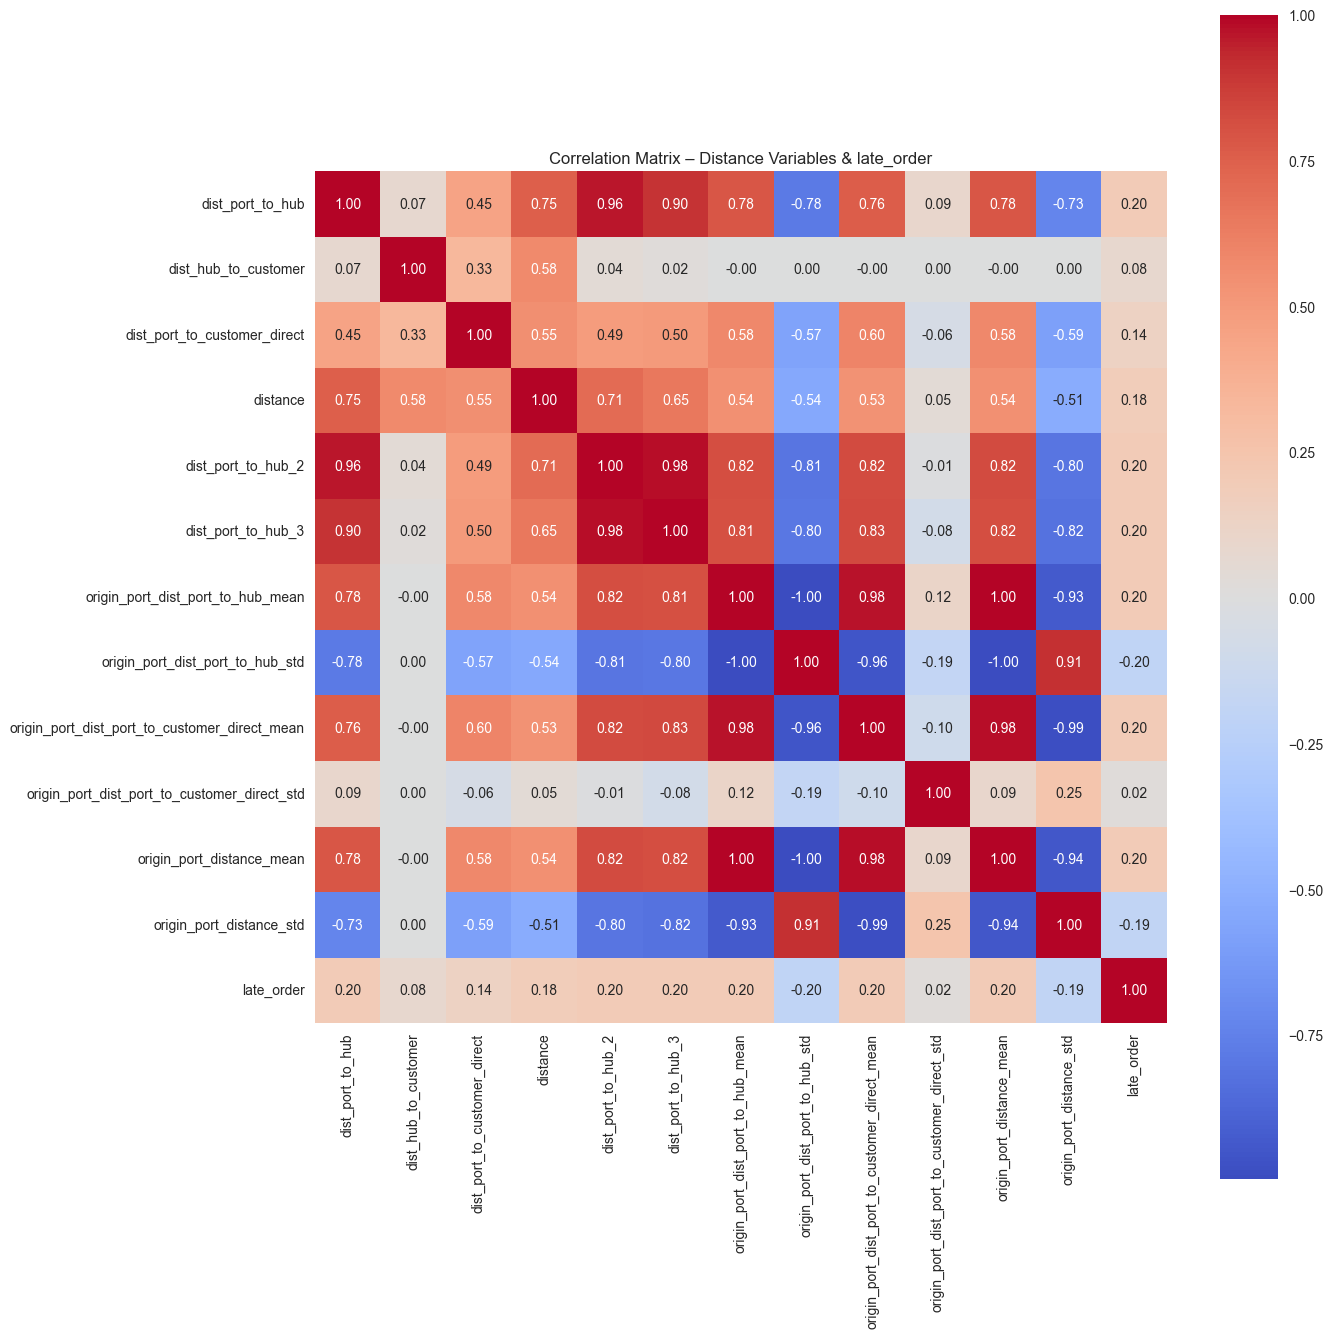

In [129]:
plt.figure(figsize=(14, 14))
sns.heatmap(
    corr_distance,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)

plt.title("Correlation Matrix – Distance Variables & late_order")
plt.tight_layout()
plt.show()

In [130]:
keep_distance = [
    "distance",
    "dist_port_to_hub",
    "origin_port_dist_port_to_hub_std"
]

In [131]:
distance_cols = [
    c for c in df.columns
    if (("dist" in c.lower() or "distance" in c.lower())
        and not c.endswith("_bin"))
]

In [132]:
drop_distance = [c for c in distance_cols if c not in keep_distance]

In [133]:
df = df.drop(columns=drop_distance)

In [134]:
df.columns

Index(['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'units', 'late_order', 'weight', 'material_handling',
       'dist_port_to_hub', 'distance', 'total_weight', 'has_hub', 'weight_bin',
       'distance_bin', 'units_bin', 'total_weight_bin', 'product_id',
       'order_id', 'hub_country', 'customer_country', 'origin_country',
       'same_country', 'route_geo', 'route_x_upl', 'weight_class',
       'weight_risk_category', '3pl_customs', 'origin_lpi', 'customer_lpi',
       'hub_lpi', 'origin_port_dist_port_to_hub_std',
       'origin_port_TO_logistic_hub', 'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_weightbyorigin_port_TO_logistic_hub',
       'zscore_unitsbyorigin_port_TO_logistic_hub',
       'zscore_weightbylogistic_hub_TO_city_customer',
       'zscore_unitsbylogistic_hub_TO_city_customer',
       'zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_unitsb

In [135]:
cat_cols = [
    'origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
    'weight_bin', 'distance_bin', 'units_bin', 'total_weight_bin',
    'order_id', 'hub_country', 'customer_country', 'origin_country',
    'route_geo', 'route_x_upl', 'weight_class', 'weight_risk_category',
    '3pl_customs', 'origin_port_TO_logistic_hub',
    'logistic_hub_TO_city_customer',
    'FULL_origin_port_TO_logistic_hub_TO_city_customer', 'same_country'
]

all_cat = cat_cols + ["late_order"]

all_cat = [c for c in all_cat if c in df.columns]

In [136]:
all_cat = ['origin_port',
 '3pl',
 'customs_procedures',
 'logistic_hub',
 'customer',
 'hub_country',
 'customer_country',
 'origin_country',
 'route_geo',
 'route_x_upl',
 'weight_risk_category',
 '3pl_customs',
 'origin_port_TO_logistic_hub',
 'logistic_hub_TO_city_customer',
 'FULL_origin_port_TO_logistic_hub_TO_city_customer',
 'same_country',
 'late_order']

In [137]:
cramer_matrix = pd.DataFrame(
    np.zeros((len(all_cat), len(all_cat))),
    index=all_cat, columns=all_cat
)

for c1 in all_cat:
    for c2 in all_cat:
        cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

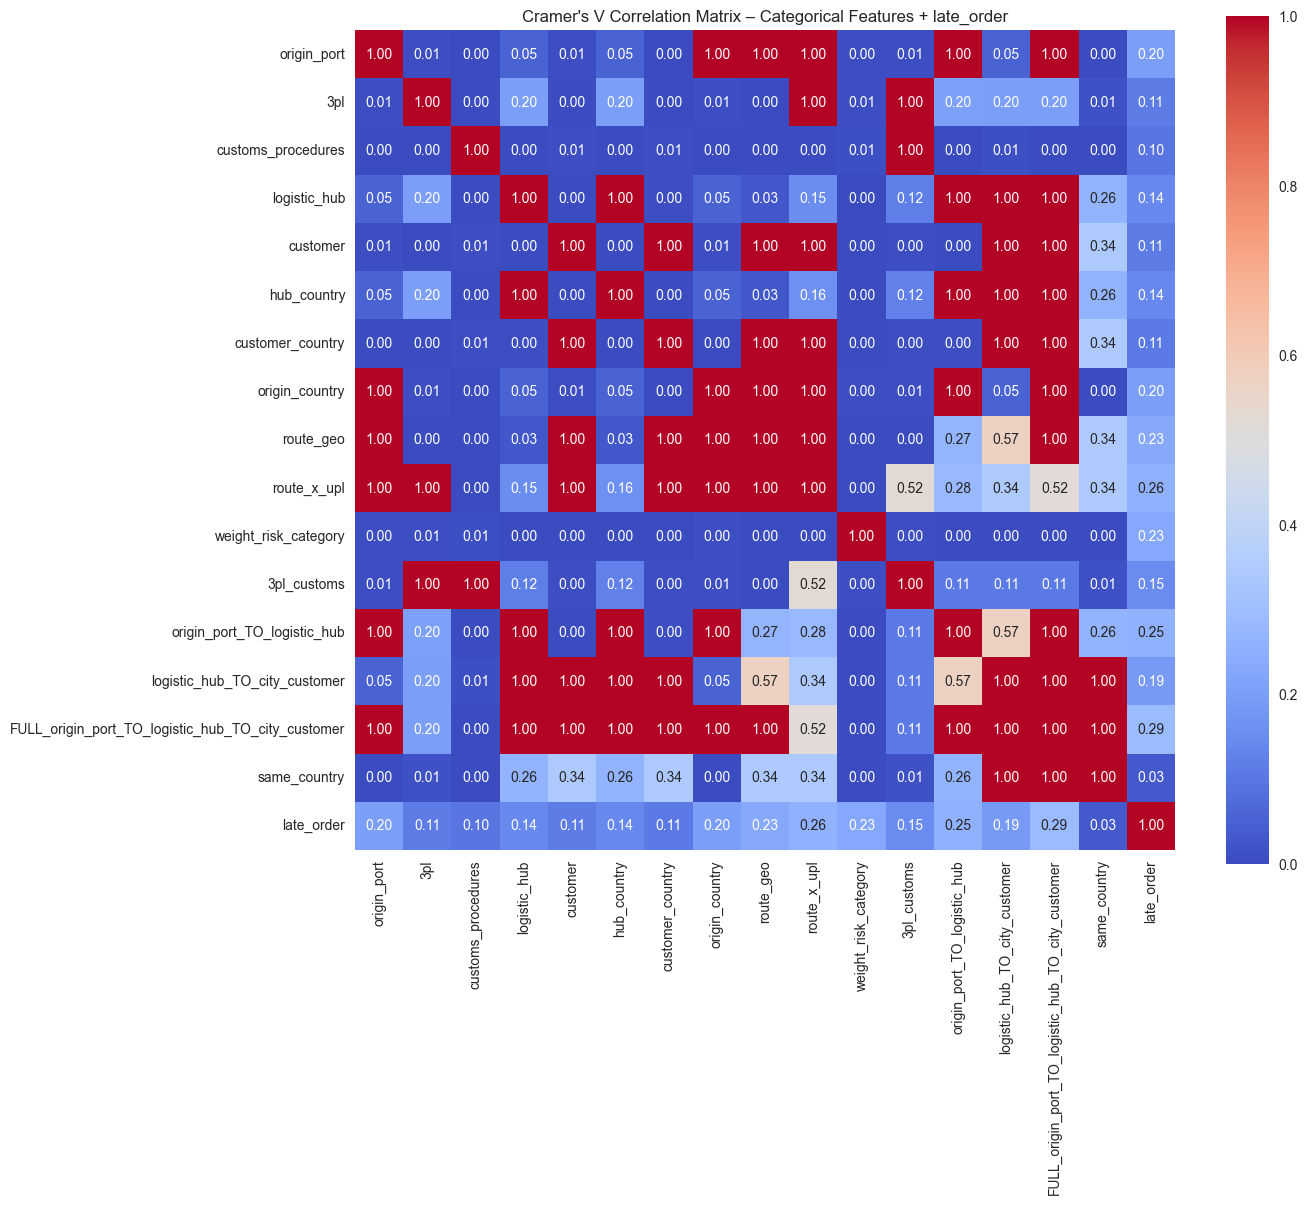

In [138]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cramer_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)

plt.title("Cramer's V Correlation Matrix – Categorical Features + late_order")
plt.tight_layout()
plt.show()

In [139]:
cols_country = [c for c in df.columns if "country" in c.lower()]
cols_country

['hub_country', 'customer_country', 'origin_country', 'same_country']

In [140]:
df = df.drop(columns=cols_country)

In [141]:
df['route_geo'] = df['origin_port'] + "_to_" + df['customer']

#interazione trasportatore-rotta
df['route_x_upl'] = df['route_geo'] + "_" + df['3pl']

C:\Users\gaiag\AppData\Local\Temp\ipykernel_22172\1792589648.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14, 12))


<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

...

<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

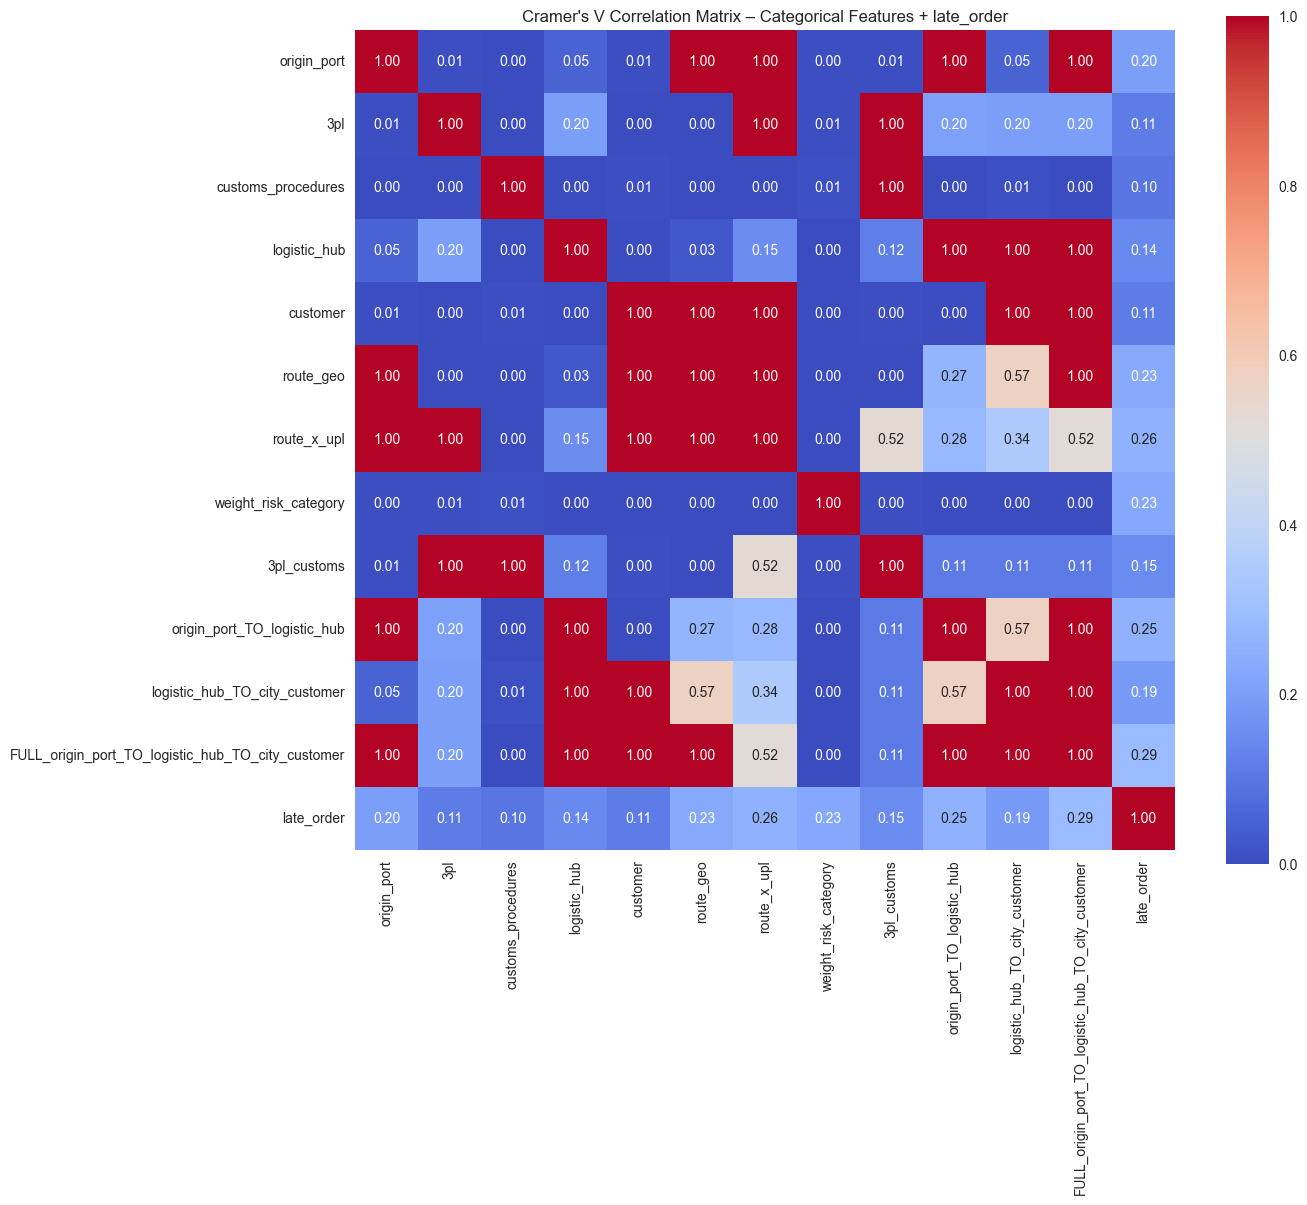

In [142]:
all_cat = ['origin_port',
 '3pl',
 'customs_procedures',
 'logistic_hub',
 'customer',
 'route_geo',
 'route_x_upl',
 'weight_risk_category',
 '3pl_customs',
 'origin_port_TO_logistic_hub',
 'logistic_hub_TO_city_customer',
 'FULL_origin_port_TO_logistic_hub_TO_city_customer',
 'late_order']

cramer_matrix = pd.DataFrame(
    np.zeros((len(all_cat), len(all_cat))),
    index=all_cat, columns=all_cat
)

for c1 in all_cat:
    for c2 in all_cat:
        cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

        plt.figure(figsize=(14, 12))
sns.heatmap(
    cramer_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)

plt.title("Cramer's V Correlation Matrix – Categorical Features + late_order")
plt.tight_layout()
plt.show()

In [143]:
df = df.drop(columns='weight_class')

In [144]:
df.to_csv("df_quasi_selezionato.csv", index=False)

### Selezione Elastic Net

In [145]:
df = df.drop(["route_geo", "route_x_upl"], axis=1)

In [146]:
df =df.dropna()

In [147]:
df.columns

Index(['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'units', 'late_order', 'weight', 'material_handling',
       'dist_port_to_hub', 'distance', 'total_weight', 'has_hub', 'weight_bin',
       'distance_bin', 'units_bin', 'total_weight_bin', 'product_id',
       'order_id', 'weight_risk_category', '3pl_customs', 'origin_lpi',
       'customer_lpi', 'hub_lpi', 'origin_port_dist_port_to_hub_std',
       'origin_port_TO_logistic_hub', 'logistic_hub_TO_city_customer',
       'FULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_weightbyorigin_port_TO_logistic_hub',
       'zscore_unitsbyorigin_port_TO_logistic_hub',
       'zscore_weightbylogistic_hub_TO_city_customer',
       'zscore_unitsbylogistic_hub_TO_city_customer',
       'zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer',
       'zscore_unitsbyFULL_origin_port_TO_logistic_hub_TO_city_customer'],
      dtype='object')

In [148]:
df = df.drop(df.filter(regex="^zscore").columns, axis=1)

In [149]:
df_dummies = df.drop(columns=['order_id','product_id'],axis=1)

In [150]:
cat_cols = df_dummies.select_dtypes(include=['object', 'category']).columns

df_dummies = pd.get_dummies(df_dummies, columns=cat_cols, drop_first=False)

In [151]:
df_dummies.shape

(113109, 1151)

In [152]:
dummy_cols = [col for col in df_dummies.columns if any(col.startswith(c + "_") for c in cat_cols)]

distribuzione = (
    df_dummies.groupby("late_order")[dummy_cols]
    .sum()
    .T
)

distribuzione.columns = ["count_target_0", "count_target_1"]

In [153]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


In [154]:
distribuzione["perc_target_1"] = (
    distribuzione["count_target_1"] / 
    (distribuzione["count_target_0"] + distribuzione["count_target_1"])
)

In [155]:
print(distribuzione["perc_target_1"])

customer_lpi                                                                      0.236
origin_port_dist_port_to_hub_std                                                  0.227
origin_port_Athens                                                                0.374
origin_port_Barcelona                                                             0.270
origin_port_Rotterdam                                                             0.167
3pl_v_001                                                                         0.395
3pl_v_002                                                                         0.199
3pl_v_003                                                                         0.250
3pl_v_004                                                                         0.257
customs_procedures_CRF                                                            0.198
customs_procedures_DTD                                                            0.251
customs_procedures_DTP          

In [156]:
filtrate = distribuzione["perc_target_1"][distribuzione["perc_target_1"] > 0.6]
print(filtrate)

total_weight_bin_4 - Q                                                          0.808
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaBordeaux      0.857
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaMarseille     0.639
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaPorto         0.692
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaStockholm     0.613
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaValencia      0.750
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLiegeHelsinki           0.636
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLilleAthens             0.717
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLilleBordeaux           0.750
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLilleBucharest          0.651
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLilleBudapest           0.661
FULL_origin_port_TO_logistic_hub_TO_city_customer_Athe

In [157]:
variabili_da_rimuovere = [
    "total_weight_bin_4 - Q",
    "FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLiegeHelsinki"
]

filtrate = filtrate.drop(labels=variabili_da_rimuovere, errors="ignore")

In [158]:
non_dummy_cols = [col for col in df_dummies.columns if col not in dummy_cols]

In [159]:
df = df_dummies[ non_dummy_cols + list(filtrate.index) ]

In [160]:
cols_da_escludere = ["order_id", "product_id"]

cat_cols = df.select_dtypes(include=["object", "category"]).columns
cat_cols = [c for c in cat_cols if c not in cols_da_escludere]

In [161]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [162]:
df_val = df.sample(frac=0.20, random_state=42)

In [163]:
X_val = df_val.drop(columns=['late_order'])
y_val = df_val['late_order']


In [164]:
df_train = df.drop(df_val.index)

In [165]:
y = df_train["late_order"]

X = df_train.drop(columns=["late_order"])

In [166]:
X.isna().sum()

units                                                                            0
weight                                                                           0
material_handling                                                                0
dist_port_to_hub                                                                 0
distance                                                                         0
total_weight                                                                     0
has_hub                                                                          0
origin_lpi                                                                       0
hub_lpi                                                                          0
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaBordeaux       0
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaMarseille      0
FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensBratislavaPorto          0
FULL

In [167]:
df_merge.columns

Index(['order_id', 'origin_port', '3pl', 'customs_procedures', 'logistic_hub',
       'customer', 'product_id', 'units', 'late_order', 'weight',
       'material_handling', 'dist_port_to_hub', 'dist_hub_to_customer',
       'dist_port_to_customer_direct', 'distance'],
      dtype='object')

In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        max_iter=1000
    ))
])

param_grid = {
    "model__l1_ratio": [0.8, 0.9, 1.0],
    "model__C": [0.0001, 0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="recall",  
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'model__C': [0.0001, 0.001, ...], 'model__l1_ratio': [0.8, 0.9, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [169]:
best_model = grid.best_estimator_["model"]
coeff = best_model.coef_[0]

selected_features = X.columns[coeff != 0]

In [170]:
for f in selected_features:
    print(f)

dist_port_to_hub


In [171]:
X.shape

(90487, 41)

In [172]:
len(selected_features)

1

### Reg Logistica

In [173]:
feature_to_exclude = ("total_weight_bin_4 - Q", 'FULL_origin_port_TO_logistic_hub_TO_city_customer_AthensLiegeHelsinki')

selected_features_clean = [f for f in selected_features if f != feature_to_exclude]

In [174]:
X_selected = X[selected_features_clean]

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty=None,     # oppure elasticnet, L2, L1
        class_weight="balanced",
        max_iter=2000
    ))
])

final_pipe.fit(X_selected, y)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,None
,dual,False
,tol,0.0001
,C,1.0


In [176]:
y_pred = final_pipe.predict(X_selected)

In [177]:
from sklearn.metrics import classification_report, recall_score

print(classification_report(y, y_pred))
print("Recall classe 1:", recall_score(y, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.51      0.63     69060
           1       0.29      0.65      0.40     21427

    accuracy                           0.54     90487
   macro avg       0.56      0.58      0.52     90487
weighted avg       0.70      0.54      0.58     90487

Recall classe 1: 0.6475008167265599


In [178]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear"   # ottimo per L1 o L2
    ))
])

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1],
    "model__penalty": ["l1", "l2"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="recall", 
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [179]:
print(grid.best_params_)
print(grid.best_score_)

{'model__C': 0.001, 'model__penalty': 'l1'}
0.6546879871699681


In [180]:
best_model = grid.best_estimator_
best_model.fit(X, y)

y_pred = best_model.predict(X)
y_prob = best_model.predict_proba(X)[:,1]


In [181]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.64      0.73     69060
           1       0.35      0.64      0.46     21427

    accuracy                           0.64     90487
   macro avg       0.60      0.64      0.59     90487
weighted avg       0.73      0.64      0.66     90487



In [182]:
counts = df_copy["product_id"].value_counts()
n_id_meno_10 = (counts < 2).sum()
print("ID con meno di 10 occorrenze:", n_id_meno_10)

ID con meno di 10 occorrenze: 4


In [183]:
df_copy['weight'].max()

np.float64(2876.0)

#### Validation

In [184]:
X_val =X_val[selected_features]

In [185]:
y_pred = final_pipe.predict(X_val)

In [186]:
y_proba = final_pipe.predict_proba(X_val)[:, 1]

In [187]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score, roc_auc_score, confusion_matrix

In [188]:
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_proba)
cm = confusion_matrix(y_val, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.5367341525948192
Precision: 0.28655215751989943
Recall: 0.6350974930362117
F1: 0.394919168591224
ROC-AUC: 0.6249973591713837
Confusion Matrix:
 [[8722 8515]
 [1965 3420]]


In [189]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.51      0.62     17237
           1       0.29      0.64      0.39      5385

    accuracy                           0.54     22622
   macro avg       0.55      0.57      0.51     22622
weighted avg       0.69      0.54      0.57     22622



In [190]:
df_copy.columns

Index(['origin_port', '3pl', 'customs_procedures', 'logistic_hub', 'customer',
       'units', 'late_order', 'weight', 'material_handling',
       'dist_port_to_hub', 'dist_hub_to_customer',
       'dist_port_to_customer_direct', 'distance', 'total_weight', 'has_hub',
       'weight_bin', 'distance_bin', 'units_bin', 'total_weight_bin',
       'product_id', 'order_id', 'hub_country', 'customer_country',
       'origin_country', 'same_country', 'weight_x_distance', 'route_geo',
       'route_x_upl', 'weight_class', 'weight_risk_category', '3pl_customs',
       'weight_vs_risk_avg', 'origin_lpi', 'customer_lpi', 'hub_lpi',
       'units_2', 'weight_2', 'dist_port_to_hub_2', 'dist_hub_to_customer_2',
       'dist_port_to_customer_direct_2', 'distance_2', 'total_weight_2',
       'units_3', 'weight_3', 'dist_port_to_hub_3', 'dist_hub_to_customer_3',
       'dist_port_to_customer_direct_3', 'distance_3', 'total_weight_3',
       'origin_port_dist_port_to_hub_mean', 'origin_port_dist_port_to

In [191]:
df_copy['zscore_weightbyFULL_origin_port_TO_logistic_hub_TO_city_customer'].max()

np.float64(3.559693947432805)